# WordNet SCAR Distribution Analysis (Improved)

`WordNet is used as a symbolic analytical tool to characterize the structural and relational distribution of generated analogies, while analogy quality is assessed separately using LLM-as-judge evaluation.`

To avoid inconsistencies across WordNet-based signals, we adopt a single implicit word sense selection strategy. Specifically, for each word pair we select the synset pair that minimizes the Jiang–Conrath distance. All subsequent WordNet measures, including shortest path length and relation type, are computed on the selected synsets.

We will compare the SCAR distribution with the generations (separated by input and model)

## Goals:
1. **Shortest Path Length** (between synsets) → Measures taxonomic distance
2. **Jiang–Conrath (JC) Distance** → Best empirical performance, combines taxonomy structure and information content
3. **Multiple Similarity Measures** → Lin, Wu-Palmer, Path similarity for robustness
4. **Relational Types** → Characterize what kind of analogy the model is producing
5. **Coverage Analysis** → Track what is/isn't in WordNet

## Improvements:
- Enhanced synset selection with multiple strategies
- Comprehensive relation extraction (hypernyms, meronyms, attributes, causes, entailments)
- Multi-level similarity measures
- Better error handling and logging
- Domain-specific synset disambiguation

In [1]:
# Cell 1: Setup, Imports, and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import warnings
from collections import defaultdict, Counter
from typing import Optional, Tuple, List, Dict, Any
warnings.filterwarnings('ignore')

# WordNet imports
import nltk
from nltk.corpus import wordnet as wn
from nltk.corpus import wordnet_ic

# Download required NLTK data
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
    nltk.download('omw-1.4')
    nltk.download('wordnet_ic')

# =============================================================================
# THESIS COLOR SCHEME
# =============================================================================
COLORS = {
    'primary': '#4682B4',      # Steel Blue
    'secondary': '#FF7F50',    # Coral Orange
    'accent1': '#5A9BD4',      # Light Steel Blue
    'accent2': '#FF9966',      # Light Coral
    'dark': '#2F5496',         # Dark Steel Blue
    'text': '#333333',         # Dark Gray
    'light': '#B0C4DE',        # Light Steel Blue (muted)
}

# Palette for 12 models (alternating steel blue and coral variations)
PALETTE_MAIN = ['#4682B4', '#FF7F50', '#5A9BD4', '#FF9966',
                '#6495ED', '#FFA07A', '#87CEEB', '#FA8072', 
                '#4169E1', '#CD5C5C', '#2F5496', '#E9967A']

# =============================================================================
# MODEL ABBREVIATIONS
# =============================================================================
MODEL_ABBREV = {
    'deepseek-r1': 'DeepSeek-R1',
    'gemini-2.5-flash-lite': 'Gemini-2.5',
    'gpt-4.1-mini': 'GPT-4.1-mini',
    'gpt-4.1-nano': 'GPT-4.1-nano',
    'gpt-oss-120b': 'GPT-OSS-120B',
    'gpt-oss-20b': 'GPT-OSS-20B',
    'grok-4-fast': 'Grok-4',
    'llama-3.1-405b-instruct': 'Llama-405B',
    'meta-llama-3-1-70b-instruct': 'Llama-70B',
    'meta-llama-3-1-8b-instruct': 'Llama-8B',
    'qwen3-14b': 'Qwen3-14B',
    'qwen3-32b': 'Qwen3-32B',
}

def get_model_abbrev(model_name):
    """Get abbreviation for model name, or return original if not found"""
    return MODEL_ABBREV.get(model_name, model_name)

# Set matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'

print("Setup complete! WordNet version:", wn.get_version())

[nltk_data] Downloading package wordnet to C:\Users\maria/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\maria/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet_ic to
[nltk_data]     C:\Users\maria/nltk_data...
[nltk_data]   Package wordnet_ic is already up-to-date!


Setup complete! WordNet version: 3.0


In [2]:
# Cell 2: Load Data
import ast
from pathlib import Path

# Set up paths
RESULTS_DIR = Path('data/results')
OUTPUT_DIR = Path('output')

# Load SCAR dataset
df_SCAR = pd.read_csv(r'..\..\data\SCAR_cleaned_manually.csv')

print(f"SCAR dataset shape: {df_SCAR.shape}")
print("\nSCAR columns:", df_SCAR.columns.tolist())
print("\nFirst few rows:")
display(df_SCAR.head())

# ============================================================================
# Build mapping table from SCAR
# ============================================================================

def extract_target_subconcept_VS_source_subconcept(row,
                                                  target_col="system_a",
                                                  source_col="system_b",
                                                  mappings_col="mappings_parsed"):
    """
    Extract individual subconcept mappings from a SCAR row.
    Returns a list of dictionaries, one per mapping.
    """
    target = row.get(target_col, None)
    source = row.get(source_col, None)
    mappings = row.get(mappings_col, None)

    # --- Make sure mappings is a list, not a string ---
    if isinstance(mappings, str):
        try:
            mappings = ast.literal_eval(mappings)
        except Exception as e:
            print(f"[WARN] Could not parse mappings_parsed for id={row.get('id')}: {e}")
            return []

    # handle missing/empty
    if not isinstance(mappings, (list, tuple)) or len(mappings) == 0:
        return []

    out = []
    for i, pair in enumerate(mappings):
        # pair should be like ['changes', 'pointer']
        if not isinstance(pair, (list, tuple)) or len(pair) < 2:
            continue

        target_sub = pair[0]
        source_sub = pair[1]

        out.append({
            "id": row.get("id", None),
            "map_idx": i,
            "target": target,
            "target_subconcept": target_sub,
            "source": source,
            "source_subconcept": source_sub,
        })

    return out


def build_mapping_table(df_SCAR: pd.DataFrame) -> pd.DataFrame:
    """
    Apply the function to all rows and build a single long-form table.
    Each row represents one subconcept mapping.
    """
    records = []
    for _, row in df_SCAR.iterrows():
        records.extend(extract_target_subconcept_VS_source_subconcept(row))
    return pd.DataFrame(records)


# Build the mapping table
print("\n" + "="*60)
print("Building mapping table from SCAR dataset...")
print("="*60)
df_map = build_mapping_table(df_SCAR)

print(f"\nMappings dataset shape: {df_map.shape}")
print("\nMappings columns:", df_map.columns.tolist())
print("\nFirst few mappings:")
display(df_map.head())

print(f"\nTotal unique SCAR pairs: {df_SCAR['id'].nunique()}")
print(f"Total subconcept mappings extracted: {len(df_map)}")
print(f"Average mappings per SCAR pair: {len(df_map) / len(df_SCAR):.2f}")


SCAR dataset shape: (400, 13)

SCAR columns: ['id', 'system_a', 'system_b', 'system_a_domain', 'system_b_domain', 'system_a_background', 'system_b_background', 'mappings_parsed', 'mapping_count', 'explanation_parsed', 'explanation_count', 'system_a_bg_wc', 'system_b_bg_wc']

First few rows:


,id,system_a,system_b,system_a_domain,system_b_domain,system_a_background,system_b_background,mappings_parsed,mapping_count,explanation_parsed,explanation_count,system_a_bg_wc,system_b_bg_wc
0,1,biological clock,clock,Biology,Engineering,The biological clock is a fundamental aspect o...,"A clock, also known as a timepiece, is a devic...","[['changes', 'pointer'], ['state', 'time'], ['...",3,['Changes correspond to pointers: In the biolo...,3,190,118
1,2,Biosphere,Library,Biology,Art,The biosphere refers to the sum of all ecosyst...,A library is much more than a building full of...,"[['biology', 'books'], ['biodiversity', 'Book ...",3,"[""Biology corresponds to books: In the biosphe...",3,110,149
2,3,Respiratory system,engine,Biology,Physics,The respiratory system is a critical biologica...,An engine or motor is a machine that transform...,"[['oxygen', 'fuel'], ['the lungs', 'combustion...",3,['Oxygen corresponds to fuel: In the respirato...,3,131,143
3,4,Spread of Pathogens,Spread of Fire,Biology,Physics,"The spread of pathogens is a serious concern, ...",Fire is a natural process that is essential fo...,"[['pathogen', 'fire'], ['crowd', 'combustibles...",3,['Pathogens correspond to fire: in the transmi...,3,127,170
4,5,Gene editing,kirigami,Biology,Art,Gene editing is a revolutionary technique in m...,Kirigami is a fascinating art form that origin...,"[['Gene', 'raw material'], ['CRISPR-Cas9 Techn...",3,['Gene corresponds to raw materials: in gene e...,3,133,130



Building mapping table from SCAR dataset...

Mappings dataset shape: (1613, 6)

Mappings columns: ['id', 'map_idx', 'target', 'target_subconcept', 'source', 'source_subconcept']

First few mappings:


,id,map_idx,target,target_subconcept,source,source_subconcept
0,1,0,biological clock,changes,clock,pointer
1,1,1,biological clock,state,clock,time
2,1,2,biological clock,adjust,clock,maintain
3,2,0,Biosphere,biology,Library,books
4,2,1,Biosphere,biodiversity,Library,Book Type



Total unique SCAR pairs: 400
Total subconcept mappings extracted: 1613
Average mappings per SCAR pair: 4.03


## WordNet Configuration and Utilities

In [3]:
print(df_SCAR["system_a_domain"].value_counts())
print(df_SCAR["system_b_domain"].value_counts())

system_a_domain
Biology        100
History         60
Physics         49
Computer        41
Chemical        37
Philosophy      31
Literature      23
Geography       19
Economy         13
Art             11
Engineering     10
Mathematics      3
Sport            3
Name: count, dtype: int64
system_b_domain
History        69
Philosophy     61
Biology        48
Engineering    45
Physics        44
Art            39
Geography      25
Literature     18
Economy        15
Computer       15
Sport          11
Chemical        5
Mathematics     5
Name: count, dtype: int64


In [4]:
# Cell 3: WordNet Setup and Configuration

# =============================================================================
# INFORMATION CONTENT CORPUS
# =============================================================================
# Brown corpus IC is standard; you can also try ic-semcor.dat
IC = wordnet_ic.ic('ic-brown.dat')

# =============================================================================
# TRIVIAL HYPERNYMS TO EXCLUDE
# =============================================================================
# These are too general to be meaningful for analogy analysis
TRIVIAL_LCS = {
    'entity.n.01',
    'abstraction.n.06',
    'physical_entity.n.01',
    'object.n.01',
    'whole.n.02',
    'thing.n.01',
    'psychological_feature.n.01',
    'cognition.n.01',
    'event.n.01',
    'act.n.02',
    'activity.n.01',
}

# =============================================================================
# DOMAIN KEYWORDS FOR DISAMBIGUATION
# =============================================================================
# Help select more relevant synsets based on domain context
DOMAIN_KEYWORDS = {
    'Biology': ['biological', 'organism', 'cell', 'gene', 'species', 'evolution', 'life'],
    'History': ['historical', 'event', 'era', 'civilization', 'revolution', 'timeline'],
    'Physics': ['physical', 'force', 'energy', 'matter', 'motion', 'particle'],
    'Computer': ['computational', 'algorithm', 'data', 'software', 'programming', 'hardware'],
    'Chemical': ['chemical', 'molecule', 'reaction', 'compound', 'element', 'substance'],
    'Philosophy': ['philosophical', 'ethics', 'logic', 'metaphysics', 'epistemology', 'reason'],
    'Literature': ['literary', 'novel', 'poetry', 'author', 'narrative', 'text'],
    'Geography': ['geographical', 'region', 'climate', 'map', 'landform', 'population'],
    'Economy': ['economic', 'market', 'trade', 'finance', 'inflation', 'growth'],
    'Art': ['artistic', 'creative', 'aesthetic', 'design', 'expression'],
    'Engineering': ['mechanical', 'electrical', 'system', 'machine', 'device', 'technology'],
    'Mathematics': ['mathematical', 'equation', 'formula', 'theorem', 'calculation'],
    'Sport': ['sporting', 'athlete', 'competition', 'training', 'fitness', 'game']
}


def get_domain_score(synset: wn.synset, domain: str) -> float:
    """
    Score how well a synset matches a domain based on definition and examples.
    Returns a score between 0 and 1.
    """
    if not domain or domain.lower() not in DOMAIN_KEYWORDS:
        return 0.0
    
    keywords = DOMAIN_KEYWORDS[domain.lower()]
    text = (synset.definition() + ' ' + ' '.join(synset.examples())).lower()
    
    matches = sum(1 for kw in keywords if kw in text)
    return matches / len(keywords) if keywords else 0.0

print("WordNet configuration loaded successfully!")
print(f"Information Content corpus: Brown")
print(f"Trivial hypernyms excluded: {len(TRIVIAL_LCS)}")
print(f"Domain disambiguation available for: {list(DOMAIN_KEYWORDS.keys())}")

WordNet configuration loaded successfully!
Information Content corpus: Brown
Trivial hypernyms excluded: 11
Domain disambiguation available for: ['Biology', 'History', 'Physics', 'Computer', 'Chemical', 'Philosophy', 'Literature', 'Geography', 'Economy', 'Art', 'Engineering', 'Mathematics', 'Sport']


## Enhanced Synset Selection

Key improvements:
1. **Multi-word handling**: Properly handles phrases with underscores
2. **Domain-aware selection**: Uses domain context for disambiguation
3. **Fallback strategies**: Multiple approaches to find best synset pairs
4. **Similarity-based selection**: Chooses synsets that maximize JCN or Wu-Palmer similarity

In [5]:
# Cell 4: Enhanced Synset Selection

def preprocess_term(term: str) -> str:
    """
    Preprocess a term for WordNet lookup.
    Handles multi-word expressions and special characters.
    """
    if not term:
        return ""
    
    # Convert to lowercase and strip
    term = str(term).lower().strip()
    
    # Replace spaces with underscores for multi-word terms
    term = term.replace(' ', '_')
    
    # Remove common articles and determiners that might interfere
    for article in ['the_', 'a_', 'an_']:
        if term.startswith(article):
            term = term[len(article):]
    
    return term


def get_all_synsets(term: str, pos_list: List) -> List[wn.synset]:
    """
    Get all possible synsets for a term across specified POS tags.
    Handles both single words and multi-word expressions.
    """
    term = preprocess_term(term)
    if not term:
        return []
    
    synsets = []
    
    # Try each POS tag
    for pos in pos_list:
        synsets.extend(wn.synsets(term, pos=pos))
    
    # If no results with underscores, try without (for multi-word terms)
    if not synsets and '_' in term:
        term_no_underscore = term.replace('_', '')
        for pos in pos_list:
            synsets.extend(wn.synsets(term_no_underscore, pos=pos))
    
    # Also try first word only as fallback
    if not synsets and '_' in term:
        first_word = term.split('_')[0]
        for pos in pos_list:
            synsets.extend(wn.synsets(first_word, pos=pos))
    
    return synsets


def safe_jcn_sim(s1: wn.synset, s2: wn.synset, ic=IC) -> Tuple[Optional[float], bool]:
    """
    Safely compute Jiang-Conrath similarity.
    Returns (similarity, validity_flag).
    
    JCN similarity can be undefined for:
    - Different POS tags
    - Synsets without IC values
    - Verbs (often problematic)
    """
    if s1 is None or s2 is None:
        return None, False
    if s1.pos() != s2.pos():
        return None, False
    if s1.pos() not in ['n', 'v']:  # JCN only works for nouns and verbs
        return None, False
    
    try:
        sim = s1.jcn_similarity(s2, ic)
        # Check for invalid values (infinity, nan)
        if sim is None or np.isinf(sim) or np.isnan(sim):
            return None, False
        return float(sim), True
    except Exception as e:
        return None, False


def safe_wup_sim(s1: wn.synset, s2: wn.synset) -> Optional[float]:
    """
    Safely compute Wu-Palmer similarity.
    More robust than JCN, works across POS tags.
    """
    if s1 is None or s2 is None:
        return None
    try:
        sim = s1.wup_similarity(s2)
        if sim is None or np.isnan(sim):
            return None
        return float(sim)
    except Exception:
        return None


def select_synsets(
    term1: str,
    term2: str,
    pos_list: List,
    ic=IC,
    domain1: str = None,
    domain2: str = None
) -> Tuple[Optional[wn.synset], Optional[wn.synset], Optional[str], str]:
    """
    Enhanced synset selection with domain awareness.
    
    Strategy:
    1. Try to maximize JCN similarity (if valid)
    2. Fall back to Wu-Palmer similarity
    3. Consider domain relevance for disambiguation
    
    Returns:
        (synset1, synset2, pos_tag_used, selection_method)
    """
    synsets1 = get_all_synsets(term1, pos_list)
    synsets2 = get_all_synsets(term2, pos_list)
    
    if not synsets1 or not synsets2:
        return None, None, None, "no_synsets"
    
    # Strategy 1: Try JCN similarity (best empirical performance)
    best_jcn = {"s1": None, "s2": None, "pos": None, "score": None, "selector": "jcn"}
    
    for pos_tag in pos_list:
        for s1 in synsets1:
            if s1.pos() != pos_tag:
                continue
            for s2 in synsets2:
                if s2.pos() != pos_tag:
                    continue
                    
                sim, ok = safe_jcn_sim(s1, s2, ic=ic)
                if not ok:
                    continue
                
                # Apply domain bonus if available
                # domain_boost = 0.0
                # if domain1:
                #     domain_boost += get_domain_score(s1, domain1) * 0.1
                # if domain2:
                #     domain_boost += get_domain_score(s2, domain2) * 0.1
                
                adjusted_sim = sim 
                
                if best_jcn["score"] is None or adjusted_sim > best_jcn["score"]:
                    best_jcn.update({
                        "s1": s1,
                        "s2": s2,
                        "pos": pos_tag,
                        "score": adjusted_sim,
                        "selector": "jcn"
                    })
    
    if best_jcn["s1"] is not None:
        return best_jcn["s1"], best_jcn["s2"], best_jcn["pos"], best_jcn["selector"]
    
    # Strategy 2: Fall back to Wu-Palmer similarity
    best_wup = {"s1": None, "s2": None, "pos": None, "score": None, "selector": "wup"}
    
    for pos_tag in pos_list:
        for s1 in synsets1:
            if s1.pos() != pos_tag:
                continue
            for s2 in synsets2:
                if s2.pos() != pos_tag:
                    continue
                    
                sim = safe_wup_sim(s1, s2)
                if sim is None:
                    continue
                
                # # Apply domain bonus
                # domain_boost = 0.0
                # if domain1:
                #     domain_boost += get_domain_score(s1, domain1) * 0.1
                # if domain2:
                #     domain_boost += get_domain_score(s2, domain2) * 0.1
                
                adjusted_sim = sim #    + domain_boost
                
                if best_wup["score"] is None or adjusted_sim > best_wup["score"]:
                    best_wup.update({
                        "s1": s1,
                        "s2": s2,
                        "pos": pos_tag,
                        "score": adjusted_sim,
                        "selector": "wup"
                    })
    
    return best_wup["s1"], best_wup["s2"], best_wup["pos"], best_wup["selector"]

print("Enhanced synset selection functions loaded!")

Enhanced synset selection functions loaded!


## Comprehensive Relation Extraction

Beyond basic is-a and part-of relations, we extract:
- **Taxonomic**: hypernyms, hyponyms, instance relations
- **Meronymic**: part-whole relationships (part, substance, member)
- **Attributes**: characteristic properties
- **Causation**: causes and entailments
- **Similarity**: antonyms and similar-to relations
- **Shared structure**: common hypernyms at meaningful depths

In [6]:
# Cell 5: Comprehensive Relation Extraction

def get_all_relations(s1: wn.synset, s2: wn.synset, min_lcs_depth: int = 4) -> Dict[str, Any]:
    """
    Extract comprehensive relational information between two synsets.
    
    Returns a dictionary with:
    - primary_relation: The strongest/most specific relation
    - all_relations: List of all detected relations
    - relation_details: Detailed information about each relation type
    """
    if s1 is None or s2 is None:
        return {
            "primary_relation": "none",
            "all_relations": [],
            "relation_details": {},
            "num_relations": 0
        }
    
    relations = []
    details = {}
    
    # 1. Identity
    if s1 == s2:
        return {
            "primary_relation": "same-synset",
            "all_relations": ["same-synset"],
            "relation_details": {"same-synset": True},
            "num_relations": 1
        }
    
    try:
        # 2. Taxonomic relations (is-a)
        s1_hypernyms = set(s1.hypernyms())
        s2_hypernyms = set(s2.hypernyms())
        
        if s1 in s2_hypernyms:
            relations.append("is-a-reverse")  # s2 is-a s1
            details["is-a-reverse"] = {"child": s2.name(), "parent": s1.name()}
        elif s2 in s1_hypernyms:
            relations.append("is-a")
            details["is-a"] = {"child": s1.name(), "parent": s2.name()}
        
        # Check for instance relations
        if hasattr(s1, 'instance_hypernyms') and s2 in s1.instance_hypernyms():
            relations.append("instance-of")
            details["instance-of"] = {"instance": s1.name(), "class": s2.name()}
        elif hasattr(s2, 'instance_hypernyms') and s1 in s2.instance_hypernyms():
            relations.append("instance-of-reverse")
            details["instance-of-reverse"] = {"instance": s2.name(), "class": s1.name()}
    except Exception as e:
        pass
    
    try:
        # 3. Meronymic relations (part-of)
        # Get all types of meronyms and holonyms
        s1_meronyms = set(
            s1.part_meronyms() + 
            s1.substance_meronyms() + 
            s1.member_meronyms()
        )
        s1_holonyms = set(
            s1.part_holonyms() + 
            s1.substance_holonyms() + 
            s1.member_holonyms()
        )
        s2_meronyms = set(
            s2.part_meronyms() + 
            s2.substance_meronyms() + 
            s2.member_meronyms()
        )
        s2_holonyms = set(
            s2.part_holonyms() + 
            s2.substance_holonyms() + 
            s2.member_holonyms()
        )
        
        if s2 in s1_meronyms:
            relations.append("has-part")
            details["has-part"] = {"whole": s1.name(), "part": s2.name()}
        elif s2 in s1_holonyms:
            relations.append("part-of")
            details["part-of"] = {"part": s1.name(), "whole": s2.name()}
        elif s1 in s2_meronyms:
            relations.append("has-part-reverse")
            details["has-part-reverse"] = {"whole": s2.name(), "part": s1.name()}
        elif s1 in s2_holonyms:
            relations.append("part-of-reverse")
            details["part-of-reverse"] = {"part": s2.name(), "whole": s1.name()}
    except Exception as e:
        pass
    
    try:
        # 4. Antonyms (lexical opposition)
        for lemma1 in s1.lemmas():
            for antonym in lemma1.antonyms():
                if antonym.synset() == s2:
                    relations.append("antonym")
                    details["antonym"] = {
                        "lemma1": lemma1.name(),
                        "lemma2": antonym.name()
                    }
                    break
    except Exception as e:
        pass
    
    try:
        # 5. Similar-to relation (primarily for adjectives)
        if hasattr(s1, 'similar_tos'):
            if s2 in s1.similar_tos():
                relations.append("similar-to")
                details["similar-to"] = {"synset1": s1.name(), "synset2": s2.name()}
    except Exception as e:
        pass
    
    try:
        # 6. Attribute relations (noun-adjective links)
        if hasattr(s1, 'attributes'):
            if s2 in s1.attributes():
                relations.append("has-attribute")
                details["has-attribute"] = {"noun": s1.name(), "attribute": s2.name()}
        if hasattr(s2, 'attributes'):
            if s1 in s2.attributes():
                relations.append("attribute-of")
                details["attribute-of"] = {"attribute": s1.name(), "noun": s2.name()}
    except Exception as e:
        pass
    
    try:
        # 7. Causation and entailment (verbs)
        if s1.pos() == 'v' and s2.pos() == 'v':
            if hasattr(s1, 'causes') and s2 in s1.causes():
                relations.append("causes")
                details["causes"] = {"cause": s1.name(), "effect": s2.name()}
            if hasattr(s1, 'entailments') and s2 in s1.entailments():
                relations.append("entails")
                details["entails"] = {"action1": s1.name(), "action2": s2.name()}
    except Exception as e:
        pass
    
    try:
        # 8. Shared hypernym (co-hyponyms or siblings)
        lcs_list = s1.lowest_common_hypernyms(s2)
        if lcs_list:
            lcs = lcs_list[0]
            lcs_depth = lcs.min_depth()
            
            # Filter out trivial hypernyms
            if lcs.name() not in TRIVIAL_LCS and lcs_depth >= min_lcs_depth:
                relations.append("shared-hypernym")
                details["shared-hypernym"] = {
                    "lcs": lcs.name(),
                    "lcs_depth": lcs_depth,
                    "lcs_definition": lcs.definition()
                }
                
                # Check if they're siblings (direct co-hyponyms)
                if lcs in s1_hypernyms and lcs in s2_hypernyms:
                    relations.append("co-hyponym")
                    details["co-hyponym"] = {
                        "parent": lcs.name(),
                        "sibling1": s1.name(),
                        "sibling2": s2.name()
                    }
    except Exception as e:
        pass
    
    # Determine primary relation (most specific)
    if not relations:
        primary = "none"
    else:
        # Priority order: more specific relations first
        priority = [
            "same-synset", "is-a", "is-a-reverse", "instance-of", "instance-of-reverse",
            "part-of", "part-of-reverse", "has-part", "has-part-reverse",
            "antonym", "similar-to", "has-attribute", "attribute-of",
            "causes", "entails",
            "co-hyponym", "shared-hypernym"
        ]
        for rel in priority:
            if rel in relations:
                primary = rel
                break
        else:
            primary = relations[0]
    
    return {
        "primary_relation": primary,
        "all_relations": relations,
        "relation_details": details,
        "num_relations": len(relations)
    }


def relation_type(s1: wn.synset, s2: wn.synset, min_lcs_depth: int = 4) -> str:
    """
    Simplified relation type for backwards compatibility.
    Returns the primary relation type.
    """
    result = get_all_relations(s1, s2, min_lcs_depth)
    return result["primary_relation"]

print("Comprehensive relation extraction functions loaded!")

Comprehensive relation extraction functions loaded!


## WordNet Metrics Computation

For each concept pair, we compute:
1. **Coverage**: Are both concepts in WordNet?
2. **Path length**: Shortest path in the hierarchy
3. **Similarity scores**: JCN, Lin, Wu-Palmer, Path similarity
4. **Relation types**: All semantic relations between concepts
5. **Structural features**: LCS depth, synset depth, etc.

In [7]:
# Cell 6: WordNet Metrics Computation

def wordnet_metrics(
    term1: str,
    term2: str,
    pos_list: List,
    ic=IC,
    domain1: str = None,
    domain2: str = None,
    include_all_relations: bool = True
) -> Dict[str, Any]:
    """
    Compute comprehensive WordNet metrics for a pair of terms.
    
    Parameters:
    -----------
    term1, term2 : str
        The two terms to compare
    pos_list : List
        List of POS tags to consider (e.g., [wn.NOUN, wn.VERB])
    ic : Information Content corpus
        For JCN and Lin similarity
    domain1, domain2 : str, optional
        Domain hints for synset disambiguation
    include_all_relations : bool
        Whether to extract all relation types (slower but more informative)
    
    Returns:
    --------
    Dict with all computed metrics
    """
    # Select best synsets
    s1, s2, pos_used, selector = select_synsets(
        term1, term2, pos_list, ic=ic, domain1=domain1, domain2=domain2
    )
    
    coverage = (s1 is not None and s2 is not None)
    
    if not coverage:
        return {
            "wn_coverage": False,
            "wn_selector": selector,
            "wn_pos": None,
            "wn_synset1": None,
            "wn_synset2": None,
            "wn_path_len": None,
            "wn_jcn_sim": None,
            "wn_jcn_valid": False,
            "wn_lin_sim": None,
            "wn_wup_sim": None,
            "wn_path_sim": None,
            "wn_rel_type": "none",
            "wn_all_relations": [],
            "wn_num_relations": 0,
        }
    
    # Shortest path length
    try:
        path_len = s1.shortest_path_distance(s2)
    except Exception:
        path_len = None
    
    # Similarity measures
    jcn_sim, jcn_valid = safe_jcn_sim(s1, s2, ic=ic)
    
    # Lin similarity (also IC-based)
    lin_sim = None
    if s1.pos() == s2.pos() and s1.pos() in ['n', 'v']:
        try:
            lin_sim = s1.lin_similarity(s2, ic)
            if lin_sim is not None and (np.isinf(lin_sim) or np.isnan(lin_sim)):
                lin_sim = None
        except Exception:
            pass
    
    # Wu-Palmer similarity
    wup_sim = safe_wup_sim(s1, s2)
    
    # Path similarity
    path_sim = None
    try:
        path_sim = s1.path_similarity(s2)
        if path_sim is not None and np.isnan(path_sim):
            path_sim = None
    except Exception:
        pass
    
    # Relation extraction
    if include_all_relations:
        rel_info = get_all_relations(s1, s2)
        rel_type = rel_info["primary_relation"]
        all_relations = rel_info["all_relations"]
        num_relations = rel_info["num_relations"]
        relation_details = rel_info["relation_details"]
    else:
        rel_type = relation_type(s1, s2)
        all_relations = [rel_type] if rel_type != "none" else []
        num_relations = len(all_relations)
        relation_details = {}
    
    # Additional structural features
    s1_depth = s1.min_depth() if s1 else None
    s2_depth = s2.min_depth() if s2 else None
    
    # LCS (Lowest Common Subsumer) depth
    lcs_depth = None
    try:
        lcs_list = s1.lowest_common_hypernyms(s2)
        if lcs_list:
            lcs_depth = lcs_list[0].min_depth()
    except Exception:
        pass
    
    return {
        "wn_coverage": True,
        "wn_selector": selector,
        "wn_pos": {wn.NOUN: "n", wn.VERB: "v", wn.ADJ: "a", wn.ADV: "r"}.get(pos_used, None),
        "wn_synset1": s1.name(),
        "wn_synset2": s2.name(),
        "wn_synset1_def": s1.definition(),
        "wn_synset2_def": s2.definition(),
        "wn_path_len": path_len,
        "wn_jcn_sim": float(jcn_sim) if jcn_valid else None,
        "wn_jcn_valid": bool(jcn_valid),
        "wn_lin_sim": float(lin_sim) if lin_sim is not None else None,
        "wn_wup_sim": float(wup_sim) if wup_sim is not None else None,
        "wn_path_sim": float(path_sim) if path_sim is not None else None,
        "wn_rel_type": rel_type,
        "wn_all_relations": all_relations,
        "wn_num_relations": num_relations,
        "wn_relation_details": relation_details,
        "wn_s1_depth": s1_depth,
        "wn_s2_depth": s2_depth,
        "wn_lcs_depth": lcs_depth,
    }


def add_wordnet_columns(
    df: pd.DataFrame,
    col1: str,
    col2: str,
    prefix: str,
    pos_list: List,
    ic=IC,
    domain_col1: str = None,
    domain_col2: str = None,
    include_all_relations: bool = True,
    verbose: bool = True
) -> pd.DataFrame:
    """
    Add WordNet metric columns to a dataframe.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe
    col1, col2 : str
        Column names containing the terms to compare
    prefix : str
        Prefix for new columns (e.g., 'sys_' or 'sub_')
    pos_list : List
        POS tags to consider
    domain_col1, domain_col2 : str, optional
        Column names containing domain information for disambiguation
    include_all_relations : bool
        Extract all relation types (slower)
    verbose : bool
        Print progress information
    
    Returns:
    --------
    pd.DataFrame with added WordNet columns
    """
    out = df.copy()
    
    if verbose:
        print(f"Processing {len(out)} rows...")
    
    def compute_row(row):
        domain1 = row[domain_col1] if domain_col1 and domain_col1 in row else None
        domain2 = row[domain_col2] if domain_col2 and domain_col2 in row else None
        return wordnet_metrics(
            row[col1],
            row[col2],
            pos_list=pos_list,
            ic=ic,
            domain1=domain1,
            domain2=domain2,
            include_all_relations=include_all_relations
        )
    
    feats = out.apply(compute_row, axis=1)
    feats_df = pd.DataFrame(feats.tolist()).add_prefix(prefix)
    result = pd.concat([out.reset_index(drop=True), feats_df.reset_index(drop=True)], axis=1)
    
    if verbose:
        coverage_rate = result[f"{prefix}wn_coverage"].mean()
        print(f"Coverage rate: {coverage_rate:.2%}")
        if f"{prefix}wn_jcn_valid" in result:
            jcn_valid_rate = result[f"{prefix}wn_jcn_valid"].mean()
            print(f"JCN valid rate: {jcn_valid_rate:.2%}")
    
    return result

print("WordNet metrics computation functions loaded!")

WordNet metrics computation functions loaded!


## Apply WordNet Metrics to Your Data

Now we'll apply the metrics to both:
1. **System pairs** (system_a ↔ system_b): Noun-only for better quality
2. **Subconcept pairs** (target ↔ source mappings): Nouns and verbs

In [8]:
# Cell 7: Apply to Your Data

print("=" * 60)
print("PROCESSING SUBCONCEPT PAIRS")
print("=" * 60)

# Subconcept pairs: try nouns then verbs
df_map_wn = add_wordnet_columns(
    df_map,
    "target_subconcept",
    "source_subconcept",
    prefix="sub_",
    pos_list=[wn.NOUN, wn.VERB],
    include_all_relations=True,
    verbose=True
)

print("\n" + "=" * 60)
print("PROCESSING SYSTEM PAIRS")
print("=" * 60)

# System pairs: noun only (better sense quality)
# Use domain columns if available
df_SCAR_wn = add_wordnet_columns(
    df_SCAR,
    "system_a",
    "system_b",
    prefix="sys_",
    pos_list=[wn.NOUN],
    domain_col1="system_a_domain" if "system_a_domain" in df_SCAR.columns else None,
    domain_col2="system_b_domain" if "system_b_domain" in df_SCAR.columns else None,
    include_all_relations=True,
    verbose=True
)

print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

print(f"\nSubconcept pairs:")
print(f"  Total pairs: {len(df_map_wn)}")
print(f"  Coverage: {df_map_wn['sub_wn_coverage'].sum()} ({df_map_wn['sub_wn_coverage'].mean():.1%})")
print(f"  JCN valid: {df_map_wn['sub_wn_jcn_valid'].sum()} ({df_map_wn['sub_wn_jcn_valid'].mean():.1%})")
print(f"\nPrimary relation types:")
print(df_map_wn['sub_wn_rel_type'].value_counts().head(10))

print(f"\n\nSystem pairs:")
print(f"  Total pairs: {len(df_SCAR_wn)}")
print(f"  Coverage: {df_SCAR_wn['sys_wn_coverage'].sum()} ({df_SCAR_wn['sys_wn_coverage'].mean():.1%})")
print(f"  JCN valid: {df_SCAR_wn['sys_wn_jcn_valid'].sum()} ({df_SCAR_wn['sys_wn_jcn_valid'].mean():.1%})")
print(f"\nPrimary relation types:")
print(df_SCAR_wn['sys_wn_rel_type'].value_counts().head(10))

# Add log-transformed JCN for easier visualization
df_map_wn["sub_log_jcn_sim"] = np.log10(df_map_wn["sub_wn_jcn_sim"].replace(0, np.nan))
df_SCAR_wn["sys_log_jcn_sim"] = np.log10(df_SCAR_wn["sys_wn_jcn_sim"].replace(0, np.nan))

print("\nProcessing complete!")

PROCESSING SUBCONCEPT PAIRS
Processing 1613 rows...


Coverage rate: 84.75%
JCN valid rate: 84.75%

PROCESSING SYSTEM PAIRS
Processing 400 rows...
Coverage rate: 78.00%
JCN valid rate: 78.00%

SUMMARY STATISTICS

Subconcept pairs:
  Total pairs: 1613
  Coverage: 1367 (84.7%)
  JCN valid: 1367 (84.7%)

Primary relation types:
sub_wn_rel_type
none               1178
shared-hypernym     279
same-synset          73
is-a                 31
co-hyponym           30
is-a-reverse         18
part-of               2
antonym               1
has-part              1
Name: count, dtype: int64


System pairs:
  Total pairs: 400
  Coverage: 312 (78.0%)
  JCN valid: 312 (78.0%)

Primary relation types:
sys_wn_rel_type
none               306
shared-hypernym     69
same-synset         13
co-hyponym           8
instance-of          2
is-a                 2
Name: count, dtype: int64

Processing complete!


## Save Results

In [9]:
# Cell 8: Save processed data

output_dir = Path('wordnet_outputs')
output_dir.mkdir(exist_ok=True)

# Save full datasets
df_map_wn.to_csv(output_dir / 'mappings_with_wordnet.csv', index=False)
df_SCAR_wn.to_csv(output_dir / 'SCAR_with_wordnet.csv', index=False)

print(f"Saved results to {output_dir}/")
print(f"  - mappings_with_wordnet.csv ({len(df_map_wn)} rows)")
print(f"  - SCAR_with_wordnet.csv ({len(df_SCAR_wn)} rows)")

Saved results to wordnet_outputs/
  - mappings_with_wordnet.csv (1613 rows)
  - SCAR_with_wordnet.csv (400 rows)


In [10]:
df_SCAR_wn.head()

,id,system_a,system_b,system_a_domain,system_b_domain,system_a_background,system_b_background,mappings_parsed,mapping_count,explanation_parsed,...,sys_wn_wup_sim,sys_wn_path_sim,sys_wn_rel_type,sys_wn_all_relations,sys_wn_num_relations,sys_wn_relation_details,sys_wn_s1_depth,sys_wn_s2_depth,sys_wn_lcs_depth,sys_log_jcn_sim
0,1,biological clock,clock,Biology,Engineering,The biological clock is a fundamental aspect o...,"A clock, also known as a timepiece, is a devic...","[['changes', 'pointer'], ['state', 'time'], ['...",3,['Changes correspond to pointers: In the biolo...,...,0.444444,0.090909,none,[],0,{},6.0,10.0,3.0,-300.0
1,2,Biosphere,Library,Biology,Art,The biosphere refers to the sum of all ecosyst...,A library is much more than a building full of...,"[['biology', 'books'], ['biodiversity', 'Book ...",3,"[""Biology corresponds to books: In the biosphe...",...,0.400000,0.100000,none,[],0,{},5.0,8.0,2.0,-300.0
2,3,Respiratory system,engine,Biology,Physics,The respiratory system is a critical biologica...,An engine or motor is a machine that transform...,"[['oxygen', 'fuel'], ['the lungs', 'combustion...",3,['Oxygen corresponds to fuel: In the respirato...,...,0.235294,0.071429,none,[],0,{},6.0,9.0,1.0,-300.0
3,4,Spread of Pathogens,Spread of Fire,Biology,Physics,"The spread of pathogens is a serious concern, ...",Fire is a natural process that is essential fo...,"[['pathogen', 'fire'], ['crowd', 'combustibles...",3,['Pathogens correspond to fire: in the transmi...,...,1.000000,1.000000,same-synset,[same-synset],1,{'same-synset': True},7.0,7.0,7.0,300.0
4,5,Gene editing,kirigami,Biology,Art,Gene editing is a revolutionary technique in m...,Kirigami is a fascinating art form that origin...,"[['Gene', 'raw material'], ['CRISPR-Cas9 Techn...",3,['Gene corresponds to raw materials: in gene e...,...,NaN,NaN,none,[],0,NaN,NaN,NaN,NaN,NaN


In [11]:
df_map_wn.head()

,id,map_idx,target,target_subconcept,source,source_subconcept,sub_wn_coverage,sub_wn_selector,sub_wn_pos,sub_wn_synset1,...,sub_wn_wup_sim,sub_wn_path_sim,sub_wn_rel_type,sub_wn_all_relations,sub_wn_num_relations,sub_wn_relation_details,sub_wn_s1_depth,sub_wn_s2_depth,sub_wn_lcs_depth,sub_log_jcn_sim
0,1,0,biological clock,changes,clock,pointer,True,jcn,n,change.n.07,...,0.588235,0.125000,shared-hypernym,[shared-hypernym],1,"{'shared-hypernym': {'lcs': 'artifact.n.01', '...",7.0,8.0,4.0,-1.081269
1,1,1,biological clock,state,clock,time,True,jcn,n,state.n.02,...,0.750000,0.333333,none,[],0,{},3.0,3.0,2.0,-0.614395
2,1,2,biological clock,adjust,clock,maintain,True,jcn,v,adjust.v.01,...,0.400000,0.250000,none,[],0,{},1.0,0.0,NaN,-1.100823
3,2,0,Biosphere,biology,Library,books,True,jcn,n,biota.n.01,...,0.800000,0.333333,none,[],0,{},4.0,4.0,3.0,-1.050699
4,2,1,Biosphere,biodiversity,Library,Book Type,True,jcn,n,biodiversity.n.01,...,0.100000,0.052632,none,[],0,{},9.0,9.0,0.0,-300.000000


## Analysis and Visualization

Answer research questions:
1. What relation types dominate per model?
2. Do high-quality analogies require low WordNet distance?
3. Which models generate more non-WordNet analogies?
4. Does added background shift structural depth?

In [12]:
# Cell 9: Analysis 1 - Relation Type Distribution by Model

if 'model' in df_map_wn.columns:
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Create cross-tabulation
    rel_by_model = pd.crosstab(
        df_map_wn['model'].map(get_model_abbrev),
        df_map_wn['sub_wn_rel_type'],
        normalize='index'
    ) * 100
    
    # Plot stacked bar chart
    rel_by_model.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        colormap='tab20'
    )
    
    ax.set_xlabel('Model', fontweight='bold')
    ax.set_ylabel('Percentage of Subconcept Pairs', fontweight='bold')
    ax.set_title('WordNet Relation Types by Model (Subconcepts)', fontweight='bold', fontsize=16)
    ax.legend(title='Relation Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(output_dir / 'relation_types_by_model.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nTop 5 relation types per model:")
    for model in rel_by_model.index[:5]:
        print(f"\n{model}:")
        print(rel_by_model.loc[model].sort_values(ascending=False).head(5))

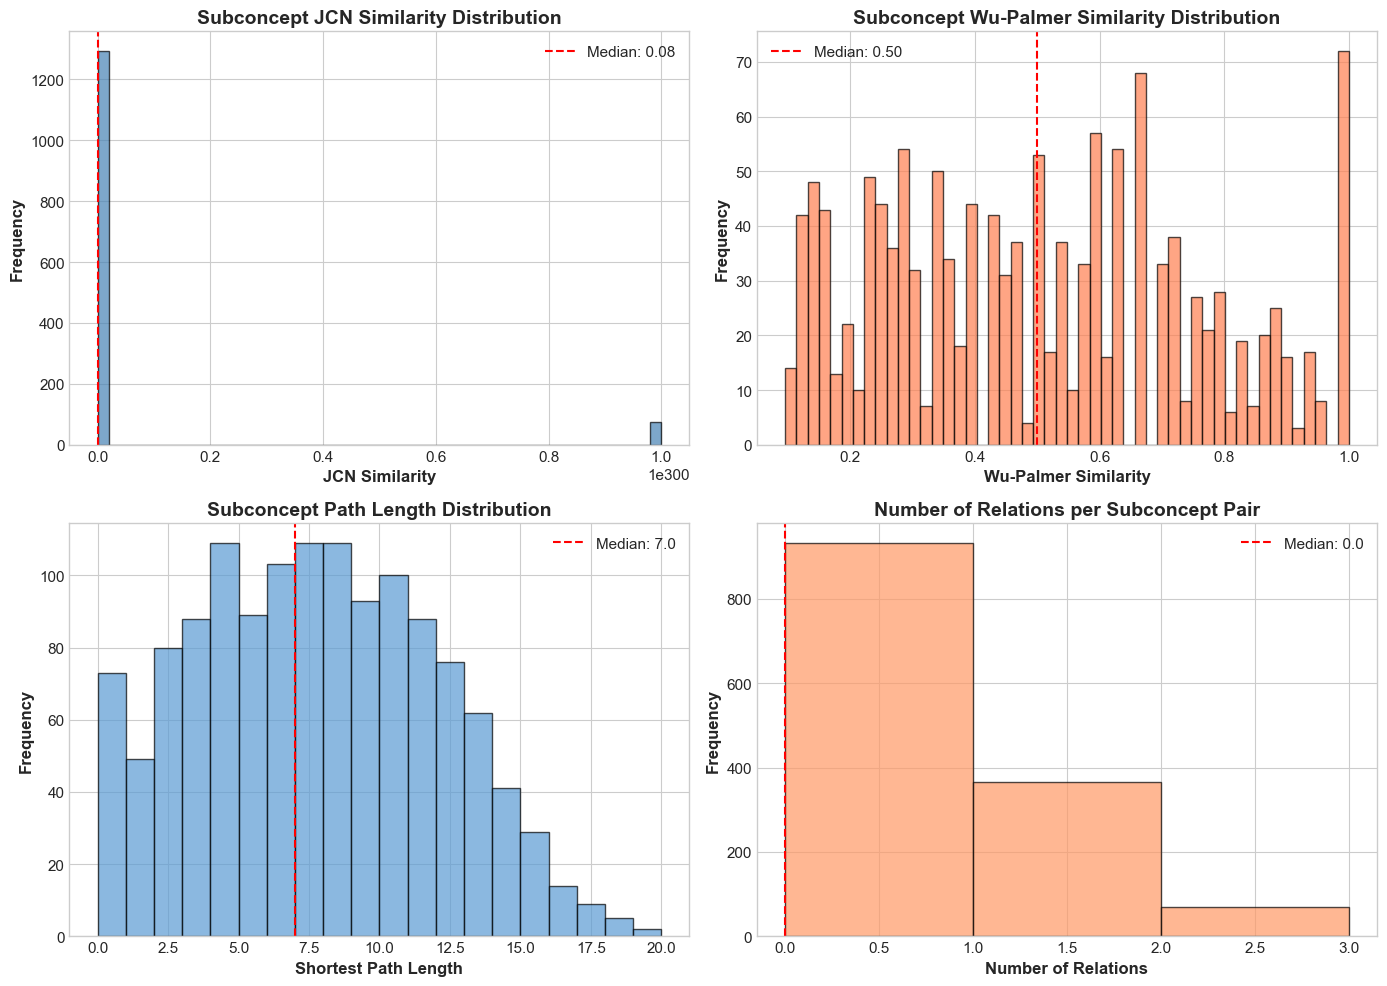


Summary Statistics:
JCN Similarity - Mean: 54133138258961226813729579784426593764104662857277307506069241532575044333377635519816450567187674444855291972871376344700701761680835341676637637126778143062657403752334526178549479879513915684109442109058237343288000865915647958852819078818923840253980902081957671933751540863912899117682461245440.000, Median: 0.079, Std: inf
Wu-Palmer Similarity - Mean: 0.504, Median: 0.500, Std: 0.254
Path Length - Mean: 7.26, Median: 7.00, Std: 4.24
Num Relations - Mean: 0.37, Median: 0.00, Max: 2


In [13]:
# Cell 10: Analysis 2 - Similarity Distributions

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# JCN Similarity (subconcepts)
valid_jcn = df_map_wn[df_map_wn['sub_wn_jcn_valid']]['sub_wn_jcn_sim']
axes[0, 0].hist(valid_jcn, bins=50, color=COLORS['primary'], alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('JCN Similarity', fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontweight='bold')
axes[0, 0].set_title('Subconcept JCN Similarity Distribution', fontweight='bold')
axes[0, 0].axvline(valid_jcn.median(), color='red', linestyle='--', label=f'Median: {valid_jcn.median():.2f}')
axes[0, 0].legend()

# Wu-Palmer Similarity (subconcepts)
valid_wup = df_map_wn[df_map_wn['sub_wn_wup_sim'].notna()]['sub_wn_wup_sim']
axes[0, 1].hist(valid_wup, bins=50, color=COLORS['secondary'], alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Wu-Palmer Similarity', fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontweight='bold')
axes[0, 1].set_title('Subconcept Wu-Palmer Similarity Distribution', fontweight='bold')
axes[0, 1].axvline(valid_wup.median(), color='red', linestyle='--', label=f'Median: {valid_wup.median():.2f}')
axes[0, 1].legend()

# Path Length (subconcepts)
valid_path = df_map_wn[df_map_wn['sub_wn_path_len'].notna()]['sub_wn_path_len']
axes[1, 0].hist(valid_path, bins=range(0, int(valid_path.max()) + 2), color=COLORS['accent1'], alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Shortest Path Length', fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontweight='bold')
axes[1, 0].set_title('Subconcept Path Length Distribution', fontweight='bold')
axes[1, 0].axvline(valid_path.median(), color='red', linestyle='--', label=f'Median: {valid_path.median():.1f}')
axes[1, 0].legend()

# Number of relations per pair
num_rels = df_map_wn[df_map_wn['sub_wn_coverage']]['sub_wn_num_relations']
axes[1, 1].hist(num_rels, bins=range(0, int(num_rels.max()) + 2), color=COLORS['accent2'], alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Number of Relations', fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontweight='bold')
axes[1, 1].set_title('Number of Relations per Subconcept Pair', fontweight='bold')
axes[1, 1].axvline(num_rels.median(), color='red', linestyle='--', label=f'Median: {num_rels.median():.1f}')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(output_dir / 'similarity_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSummary Statistics:")
print(f"JCN Similarity - Mean: {valid_jcn.mean():.3f}, Median: {valid_jcn.median():.3f}, Std: {valid_jcn.std():.3f}")
print(f"Wu-Palmer Similarity - Mean: {valid_wup.mean():.3f}, Median: {valid_wup.median():.3f}, Std: {valid_wup.std():.3f}")
print(f"Path Length - Mean: {valid_path.mean():.2f}, Median: {valid_path.median():.2f}, Std: {valid_path.std():.2f}")
print(f"Num Relations - Mean: {num_rels.mean():.2f}, Median: {num_rels.median():.2f}, Max: {num_rels.max():.0f}")

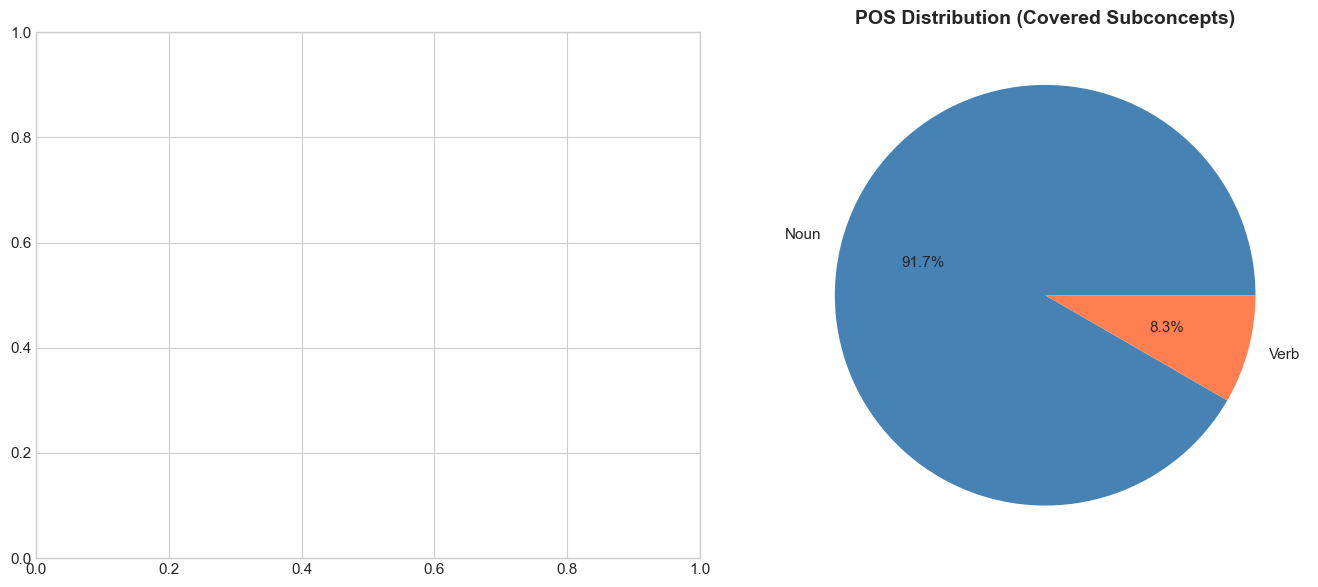


Coverage Statistics:
Overall subconcept coverage: 84.7%
Overall system coverage: 78.0%

POS distribution for covered subconcepts:
Noun    1253
Verb     114
Name: count, dtype: int64


In [14]:
# Cell 11: Analysis 3 - Coverage Analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

if 'model' in df_map_wn.columns:
    # Coverage by model
    coverage_by_model = df_map_wn.groupby('model')['sub_wn_coverage'].mean() * 100
    coverage_by_model = coverage_by_model.sort_values(ascending=False)
    coverage_by_model.index = [get_model_abbrev(m) for m in coverage_by_model.index]
    
    coverage_by_model.plot(kind='barh', ax=axes[0], color=COLORS['primary'], edgecolor='black')
    axes[0].set_xlabel('Coverage (%)', fontweight='bold')
    axes[0].set_ylabel('Model', fontweight='bold')
    axes[0].set_title('WordNet Coverage by Model (Subconcepts)', fontweight='bold')
    axes[0].axvline(coverage_by_model.mean(), color='red', linestyle='--', label=f'Mean: {coverage_by_model.mean():.1f}%')
    axes[0].legend()

# POS distribution for covered pairs
pos_dist = df_map_wn[df_map_wn['sub_wn_coverage']]['sub_wn_pos'].value_counts()
pos_labels = {'n': 'Noun', 'v': 'Verb', 'a': 'Adjective', 'r': 'Adverb'}
pos_dist.index = [pos_labels.get(p, p) for p in pos_dist.index]

axes[1].pie(pos_dist, labels=pos_dist.index, autopct='%1.1f%%', colors=PALETTE_MAIN[:len(pos_dist)])
axes[1].set_title('POS Distribution (Covered Subconcepts)', fontweight='bold')

plt.tight_layout()
plt.savefig(output_dir / 'coverage_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCoverage Statistics:")
print(f"Overall subconcept coverage: {df_map_wn['sub_wn_coverage'].mean():.1%}")
print(f"Overall system coverage: {df_SCAR_wn['sys_wn_coverage'].mean():.1%}")
print(f"\nPOS distribution for covered subconcepts:")
print(pos_dist)

In [15]:
# Cell 12: Analysis 4 - Relation Richness
# Compare models by how many semantic relations they capture

if 'model' in df_map_wn.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Average number of relations per model
    rel_richness = df_map_wn[df_map_wn['sub_wn_coverage']].groupby('model')['sub_wn_num_relations'].agg(['mean', 'std'])
    rel_richness = rel_richness.sort_values('mean', ascending=False)
    rel_richness.index = [get_model_abbrev(m) for m in rel_richness.index]
    
    rel_richness['mean'].plot(kind='barh', xerr=rel_richness['std'], ax=axes[0], 
                              color=COLORS['primary'], edgecolor='black', capsize=4)
    axes[0].set_xlabel('Average Number of Relations', fontweight='bold')
    axes[0].set_ylabel('Model', fontweight='bold')
    axes[0].set_title('Semantic Relation Richness by Model', fontweight='bold')
    
    # Distribution of multi-relation pairs
    multi_rel = df_map_wn[df_map_wn['sub_wn_coverage']].copy()
    multi_rel['relation_category'] = pd.cut(
        multi_rel['sub_wn_num_relations'],
        bins=[0, 1, 2, 3, 100],
        labels=['0-1', '2', '3', '4+']
    )
    
    rel_cat_dist = multi_rel['relation_category'].value_counts().sort_index()
    axes[1].pie(rel_cat_dist, labels=rel_cat_dist.index, autopct='%1.1f%%', 
                colors=PALETTE_MAIN[:len(rel_cat_dist)])
    axes[1].set_title('Distribution of Relation Counts', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(output_dir / 'relation_richness.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nRelation Richness Statistics:")
    print(rel_richness)
    print(f"\nPairs with multiple relations: {(multi_rel['sub_wn_num_relations'] > 1).mean():.1%}")

In [16]:
# Cell 13: Example Relations Analysis
# Show some interesting examples of multi-relation pairs

print("=" * 80)
print("EXAMPLES OF RICH SEMANTIC RELATIONS")
print("=" * 80)

rich_pairs = df_map_wn[df_map_wn['sub_wn_num_relations'] >= 2].copy()

if len(rich_pairs) > 0:
    # Sample some interesting pairs
    for idx, row in rich_pairs.sample(min(5, len(rich_pairs))).iterrows():
        print(f"\n{'─' * 80}")
        print(f"Pair: '{row['target_subconcept']}' ↔ '{row['source_subconcept']}'")
        print(f"Synsets: {row['sub_wn_synset1']} ↔ {row['sub_wn_synset2']}")
        print(f"\nDefinitions:")
        print(f"  1: {row['sub_wn_synset1_def']}")
        print(f"  2: {row['sub_wn_synset2_def']}")
        print(f"\nPrimary relation: {row['sub_wn_rel_type']}")
        print(f"All relations ({row['sub_wn_num_relations']}): {', '.join(row['sub_wn_all_relations'])}")
        print(f"\nSimilarity scores:")
        if row['sub_wn_jcn_valid']:
            print(f"  JCN: {row['sub_wn_jcn_sim']:.3f}")
        if pd.notna(row['sub_wn_wup_sim']):
            print(f"  Wu-Palmer: {row['sub_wn_wup_sim']:.3f}")
        if pd.notna(row['sub_wn_path_len']):
            print(f"  Path length: {row['sub_wn_path_len']}")
else:
    print("No pairs with multiple relations found.")

print(f"\n{'═' * 80}")

EXAMPLES OF RICH SEMANTIC RELATIONS

────────────────────────────────────────────────────────────────────────────────
Pair: 'water' ↔ 'air'
Synsets: water.n.03 ↔ air.n.06

Definitions:
  1: once thought to be one of four elements composing the universe (Empedocles)
  2: once thought to be one of four elements composing the universe (Empedocles)

Primary relation: co-hyponym
All relations (2): shared-hypernym, co-hyponym

Similarity scores:
  JCN: 0.353
  Wu-Palmer: 0.857
  Path length: 2.0

────────────────────────────────────────────────────────────────────────────────
Pair: 'budget' ↔ 'schedule'
Synsets: budget.n.02 ↔ agenda.n.01

Definitions:
  1: a summary of intended expenditures along with proposals for how to meet them
  2: a temporally organized plan for matters to be attended to

Primary relation: co-hyponym
All relations (2): shared-hypernym, co-hyponym

Similarity scores:
  JCN: 0.119
  Wu-Palmer: 0.875
  Path length: 2.0

────────────────────────────────────────────────────

## Export Summary Report

In [17]:
# Cell 14: Generate Summary Report

report_lines = []
report_lines.append("=" * 80)
report_lines.append("WORDNET SCAR ANALYSIS - SUMMARY REPORT")
report_lines.append("=" * 80)
report_lines.append("")

# Dataset statistics
report_lines.append("DATASET STATISTICS:")
report_lines.append("-" * 40)
report_lines.append(f"System pairs: {len(df_SCAR_wn)}")
report_lines.append(f"Subconcept pairs: {len(df_map_wn)}")
report_lines.append("")

# Coverage
report_lines.append("WORDNET COVERAGE:")
report_lines.append("-" * 40)
report_lines.append(f"System pairs in WordNet: {df_SCAR_wn['sys_wn_coverage'].sum()} ({df_SCAR_wn['sys_wn_coverage'].mean():.1%})")
report_lines.append(f"Subconcept pairs in WordNet: {df_map_wn['sub_wn_coverage'].sum()} ({df_map_wn['sub_wn_coverage'].mean():.1%})")
report_lines.append("")

# Similarity metrics
report_lines.append("SIMILARITY METRICS (Subconcepts):")
report_lines.append("-" * 40)
valid_jcn = df_map_wn[df_map_wn['sub_wn_jcn_valid']]['sub_wn_jcn_sim']
valid_wup = df_map_wn[df_map_wn['sub_wn_wup_sim'].notna()]['sub_wn_wup_sim']
valid_path = df_map_wn[df_map_wn['sub_wn_path_len'].notna()]['sub_wn_path_len']
report_lines.append("")

report_lines.append(f"JCN Similarity (n={len(valid_jcn)}):")
report_lines.append(f"  Mean: {valid_jcn.mean():.3f}, Median: {valid_jcn.median():.3f}, Std: {valid_jcn.std():.3f}")
report_lines.append(f"Wu-Palmer Similarity (n={len(valid_wup)}):")
report_lines.append(f"  Mean: {valid_wup.mean():.3f}, Median: {valid_wup.median():.3f}, Std: {valid_wup.std():.3f}")
report_lines.append(f"Path Length (n={len(valid_path)}):")
report_lines.append(f"  Mean: {valid_path.mean():.2f}, Median: {valid_path.median():.2f}, Std: {valid_path.std():.2f}")
report_lines.append("")
# Similarity metrics
report_lines.append("SIMILARITY METRICS (Systems):")
report_lines.append("-" * 40)
valid_jcn = df_SCAR_wn[df_SCAR_wn['sys_wn_jcn_valid']]['sys_wn_jcn_sim']
valid_wup = df_SCAR_wn[df_SCAR_wn['sys_wn_wup_sim'].notna()]['sys_wn_wup_sim']
valid_path = df_SCAR_wn[df_SCAR_wn['sys_wn_path_len'].notna()]['sys_wn_path_len']
report_lines.append("")

report_lines.append(f"JCN Similarity (n={len(valid_jcn)}):")
report_lines.append(f"  Mean: {valid_jcn.mean():.3f}, Median: {valid_jcn.median():.3f}, Std: {valid_jcn.std():.3f}")
report_lines.append(f"Wu-Palmer Similarity (n={len(valid_wup)}):")
report_lines.append(f"  Mean: {valid_wup.mean():.3f}, Median: {valid_wup.median():.3f}, Std: {valid_wup.std():.3f}")
report_lines.append(f"Path Length (n={len(valid_path)}):")
report_lines.append(f"  Mean: {valid_path.mean():.2f}, Median: {valid_path.median():.2f}, Std: {valid_path.std():.2f}")
report_lines.append("")

# Relation types
report_lines.append("TOP RELATION TYPES (Subconcepts):")
report_lines.append("-" * 40)
top_rels = df_map_wn['sub_wn_rel_type'].value_counts().head(10)
for rel, count in top_rels.items():
    report_lines.append(f"  {rel}: {count} ({count/len(df_map_wn)*100:.1f}%)")
report_lines.append("")

# Relation richness
num_rels = df_map_wn[df_map_wn['sub_wn_coverage']]['sub_wn_num_relations']
report_lines.append("RELATION RICHNESS:")
report_lines.append("-" * 40)
report_lines.append(f"Average relations per pair: {num_rels.mean():.2f}")
report_lines.append(f"Pairs with multiple relations: {(num_rels > 1).sum()} ({(num_rels > 1).mean():.1%})")
report_lines.append(f"Maximum relations in a pair: {num_rels.max():.0f}")
report_lines.append("")

report_lines.append("=" * 80)

report_lines.append("TOP RELATION TYPES (Systems):")
report_lines.append("-" * 40)
top_rels = df_SCAR_wn['sys_wn_rel_type'].value_counts().head(10)
for rel, count in top_rels.items():
    report_lines.append(f"  {rel}: {count} ({count/len(df_SCAR_wn)*100:.1f}%)")
report_lines.append("")


# Relation richness
num_rels = df_SCAR_wn[df_SCAR_wn['sys_wn_coverage']]['sys_wn_num_relations']
report_lines.append("RELATION RICHNESS:")
report_lines.append("-" * 40)
report_lines.append(f"Average relations per pair: {num_rels.mean():.2f}")
report_lines.append(f"Pairs with multiple relations: {(num_rels > 1).sum()} ({(num_rels > 1).mean():.1%})")
report_lines.append(f"Maximum relations in a pair: {num_rels.max():.0f}")
report_lines.append("")

report_lines.append("=" * 80)

# Write to file
report_text = "\n".join(report_lines)
with open(output_dir / 'analysis_summary.txt', 'w') as f:
    f.write(report_text)

print(report_text)
print(f"\nSummary report saved to {output_dir / 'analysis_summary.txt'}")

WORDNET SCAR ANALYSIS - SUMMARY REPORT

DATASET STATISTICS:
----------------------------------------
System pairs: 400
Subconcept pairs: 1613

WORDNET COVERAGE:
----------------------------------------
System pairs in WordNet: 312 (78.0%)
Subconcept pairs in WordNet: 1367 (84.7%)

SIMILARITY METRICS (Subconcepts):
----------------------------------------

JCN Similarity (n=1367):
  Mean: 54133138258961226813729579784426593764104662857277307506069241532575044333377635519816450567187674444855291972871376344700701761680835341676637637126778143062657403752334526178549479879513915684109442109058237343288000865915647958852819078818923840253980902081957671933751540863912899117682461245440.000, Median: 0.079, Std: inf
Wu-Palmer Similarity (n=1367):
  Mean: 0.504, Median: 0.500, Std: 0.254
Path Length (n=1328):
  Mean: 7.26, Median: 7.00, Std: 4.24

SIMILARITY METRICS (Systems):
----------------------------------------

JCN Similarity (n=312):
  Mean: 4166666666666666420743717164044543911874088

## Try on Generated data

In [18]:
# Cell 15: Generate Summary Report for Generated Data
import ast
import json
from pathlib import Path

# Load the generated results
results_dir = Path('results')
df_targetonly = pd.read_csv(results_dir / 'all_results_targetonly_rerank.csv')
df_withsub = pd.read_csv(results_dir / 'all_results_withsub_rerank.csv')

print(f"Loaded targetonly results: {len(df_targetonly)} rows")
print(f"Loaded withsub results: {len(df_withsub)} rows")

# Get unique models
models_targetonly = sorted(df_targetonly['model'].unique())
models_withsub = sorted(df_withsub['model'].unique())
all_models = sorted(set(models_targetonly + models_withsub))

print(f"\nModels in targetonly: {len(models_targetonly)}")
print(f"Models in withsub: {len(models_withsub)}")
print(f"Total unique models: {len(all_models)}")
print(f"Models: {all_models}")

# Create output directory for summaries
summary_output_dir = Path('wordnet_outputs/generated_summaries')
summary_output_dir.mkdir(parents=True, exist_ok=True)

def parse_json_column(value):
    """Safely parse JSON column that might be string or already parsed"""
    if pd.isna(value):
        return []
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except:
            try:
                return json.loads(value)
            except:
                return []
    return value if isinstance(value, list) else []

def extract_generated_mappings(row, mode='targetonly'):
    """
    Extract mappings from generated data.
    For targetonly: use target -> generated_analogies (top1_rerank or top1_embedding)
    For withsub: use target_subconcepts -> generated_subconcepts
    """
    target = row.get('target', '')
    id_val = row.get('id', None)
    
    mappings = []
    
    if mode == 'targetonly':
        # For targetonly, map target to each generated analogy
        generated_analogies = parse_json_column(row.get('generated_analogies', []))
        # Also check top1_rerank if available
        top1 = row.get('top1_rerank', None)
        if pd.notna(top1) and top1:
            generated_analogies = [top1] + [a for a in generated_analogies if a != top1]
        
        for i, analogy in enumerate(generated_analogies):
            if analogy and isinstance(analogy, str):
                mappings.append({
                    "id": id_val,
                    "map_idx": i,
                    "target": target,
                    "target_subconcept": target,  # Use target as subconcept for targetonly
                    "source": analogy,
                    "source_subconcept": analogy,
                    "model": row.get('model', ''),
                    "mode": mode
                })
    
    elif mode == 'withsub':
        # For withsub, map target_subconcepts to generated_subconcepts
        target_subconcepts_str = row.get('target_subconcepts', '')
        generated_subconcepts = parse_json_column(row.get('generated_subconcepts', []))
        
        # Parse target_subconcepts (comma-separated string)
        if isinstance(target_subconcepts_str, str):
            target_subconcepts_list = [s.strip() for s in target_subconcepts_str.split(',') if s.strip()]
        else:
            target_subconcepts_list = []
        
        # Match target subconcepts with generated subconcepts
        # Each generated analogy should have corresponding subconcepts
        generated_analogies = parse_json_column(row.get('generated_analogies', []))
        
        for i, analogy in enumerate(generated_analogies):
            if i < len(generated_subconcepts) and generated_subconcepts[i]:
                # Parse the subconcept string (comma-separated)
                gen_subconcepts_str = generated_subconcepts[i]
                if isinstance(gen_subconcepts_str, str):
                    gen_subconcepts_list = [s.strip() for s in gen_subconcepts_str.split(',') if s.strip()]
                else:
                    gen_subconcepts_list = []
                
                # Create mappings for each target subconcept to corresponding generated subconcept
                for j, target_sub in enumerate(target_subconcepts_list):
                    source_sub = gen_subconcepts_list[j] if j < len(gen_subconcepts_list) else analogy
                    mappings.append({
                        "id": id_val,
                        "map_idx": i * len(target_subconcepts_list) + j,
                        "target": target,
                        "target_subconcept": target_sub,
                        "source": analogy,
                        "source_subconcept": source_sub,
                        "model": row.get('model', ''),
                        "mode": mode
                    })
    
    return mappings

def process_model_mode(df_results, model_name, mode_name, df_SCAR):
    """Process a specific model-mode combination and generate WordNet metrics"""
    print(f"\n{'='*80}")
    print(f"Processing: {model_name} - {mode_name}")
    print(f"{'='*80}")
    
    # Filter for this model and mode
    df_filtered = df_results[
        (df_results['model'] == model_name) & 
        (df_results['mode'] == mode_name)
    ].copy()
    
    if len(df_filtered) == 0:
        print(f"No data found for {model_name} - {mode_name}")
        return None
    
    print(f"Found {len(df_filtered)} records")
    
    # Extract mappings
    all_mappings = []
    for _, row in df_filtered.iterrows():
        mappings = extract_generated_mappings(row, mode=mode_name)
        all_mappings.extend(mappings)
    
    if len(all_mappings) == 0:
        print(f"No mappings extracted for {model_name} - {mode_name}")
        return None
    
    df_gen_map = pd.DataFrame(all_mappings)
    print(f"Extracted {len(df_gen_map)} mappings")
    
    # Apply WordNet metrics to subconcept pairs
    print("Computing WordNet metrics...")
    df_gen_map_wn = add_wordnet_columns(
        df_gen_map,
        "target_subconcept",
        "source_subconcept",
        prefix="gen_",
        pos_list=[wn.NOUN, wn.VERB],
        include_all_relations=True,
        verbose=False
    )
    
    # Also compute metrics for target-source pairs (system level)
    df_gen_sys = df_filtered[['id', 'target']].copy()
    
    def get_source(row):
        """Get the best source analogy for this record"""
        record = df_filtered[df_filtered['id'] == row['id']].iloc[0]
        # Try top1_rerank first, then top1_embedding, then top1_baseline
        if pd.notna(record.get('top1_rerank')) and record.get('top1_rerank'):
            return record['top1_rerank']
        elif pd.notna(record.get('top1_embedding')) and record.get('top1_embedding'):
            return record['top1_embedding']
        elif pd.notna(record.get('top1_baseline')) and record.get('top1_baseline'):
            return record['top1_baseline']
        return ''
    
    df_gen_sys['source'] = df_gen_sys.apply(get_source, axis=1)
    df_gen_sys = df_gen_sys[df_gen_sys['source'] != ''].copy()
    
    if len(df_gen_sys) > 0:
        # Merge with SCAR to get domain info
        df_gen_sys = df_gen_sys.merge(
            df_SCAR[['id', 'system_a_domain', 'system_b_domain']],
            on='id',
            how='left'
        )
        
        df_gen_sys_wn = add_wordnet_columns(
            df_gen_sys,
            "target",
            "source",
            prefix="gen_sys_",
            pos_list=[wn.NOUN],
            domain_col1="system_a_domain",
            domain_col2=None,
            include_all_relations=True,
            verbose=False
        )
    else:
        df_gen_sys_wn = pd.DataFrame()
    
    return {
        'model': model_name,
        'mode': mode_name,
        'df_mappings': df_gen_map_wn,
        'df_systems': df_gen_sys_wn,
        'num_records': len(df_filtered),
        'num_mappings': len(df_gen_map_wn)
    }

def generate_summary_report(result_dict, df_SCAR_wn, df_map_wn):
    """Generate a summary report comparing generated data with SCAR"""
    model_name = result_dict['model']
    mode_name = result_dict['mode']
    df_gen_map = result_dict['df_mappings']
    df_gen_sys = result_dict['df_systems']
    
    report_lines = []
    report_lines.append("=" * 80)
    report_lines.append(f"WORDNET ANALYSIS SUMMARY: {get_model_abbrev(model_name)} - {mode_name.upper()}")
    report_lines.append("=" * 80)
    report_lines.append("")
    
    # Dataset statistics
    report_lines.append("DATASET STATISTICS:")
    report_lines.append("-" * 40)
    report_lines.append(f"Generated records: {result_dict['num_records']}")
    report_lines.append(f"Generated mappings: {result_dict['num_mappings']}")
    report_lines.append(f"SCAR system pairs: {len(df_SCAR_wn)}")
    report_lines.append(f"SCAR subconcept pairs: {len(df_map_wn)}")
    report_lines.append("")
    
    # Coverage comparison
    report_lines.append("WORDNET COVERAGE COMPARISON:")
    report_lines.append("-" * 40)
    if len(df_gen_map) > 0:
        gen_coverage = df_gen_map['gen_wn_coverage'].mean() * 100
        report_lines.append(f"Generated mappings coverage: {gen_coverage:.1f}%")
    else:
        report_lines.append("Generated mappings coverage: N/A (no mappings)")
    
    scar_coverage = df_map_wn['sub_wn_coverage'].mean() * 100
    report_lines.append(f"SCAR subconcept coverage: {scar_coverage:.1f}%")
    
    if len(df_gen_sys) > 0:
        gen_sys_coverage = df_gen_sys['gen_sys_wn_coverage'].mean() * 100
        report_lines.append(f"Generated system pairs coverage: {gen_sys_coverage:.1f}%")
    else:
        report_lines.append("Generated system pairs coverage: N/A")
    
    scar_sys_coverage = df_SCAR_wn['sys_wn_coverage'].mean() * 100
    report_lines.append(f"SCAR system pairs coverage: {scar_sys_coverage:.1f}%")
    report_lines.append("")
    
    # Similarity metrics comparison (subconcepts)
    if len(df_gen_map) > 0 and df_gen_map['gen_wn_jcn_valid'].sum() > 0:
        report_lines.append("SIMILARITY METRICS COMPARISON (Subconcepts):")
        report_lines.append("-" * 40)
        
        gen_jcn = df_gen_map[df_gen_map['gen_wn_jcn_valid']]['gen_wn_jcn_sim']
        scar_jcn = df_map_wn[df_map_wn['sub_wn_jcn_valid']]['sub_wn_jcn_sim']
        
        if len(gen_jcn) > 0:
            report_lines.append(f"Generated JCN - Mean: {gen_jcn.mean():.3f}, Median: {gen_jcn.median():.3f}")
        if len(scar_jcn) > 0:
            report_lines.append(f"SCAR JCN - Mean: {scar_jcn.mean():.3f}, Median: {scar_jcn.median():.3f}")
        
        gen_wup = df_gen_map[df_gen_map['gen_wn_wup_sim'].notna()]['gen_wn_wup_sim']
        scar_wup = df_map_wn[df_map_wn['sub_wn_wup_sim'].notna()]['sub_wn_wup_sim']
        
        if len(gen_wup) > 0:
            report_lines.append(f"Generated Wu-Palmer - Mean: {gen_wup.mean():.3f}, Median: {gen_wup.median():.3f}")
        if len(scar_wup) > 0:
            report_lines.append(f"SCAR Wu-Palmer - Mean: {scar_wup.mean():.3f}, Median: {scar_wup.median():.3f}")
        
        gen_path = df_gen_map[df_gen_map['gen_wn_path_len'].notna()]['gen_wn_path_len']
        scar_path = df_map_wn[df_map_wn['sub_wn_path_len'].notna()]['sub_wn_path_len']
        
        if len(gen_path) > 0:
            report_lines.append(f"Generated Path Length - Mean: {gen_path.mean():.2f}, Median: {gen_path.median():.2f}")
        if len(scar_path) > 0:
            report_lines.append(f"SCAR Path Length - Mean: {scar_path.mean():.2f}, Median: {scar_path.median():.2f}")
        report_lines.append("")
    
    # Relation types comparison
    if len(df_gen_map) > 0:
        report_lines.append("RELATION TYPES COMPARISON (Subconcepts):")
        report_lines.append("-" * 40)
        report_lines.append("Generated top relations:")
        gen_rels = df_gen_map['gen_wn_rel_type'].value_counts().head(5)
        for rel, count in gen_rels.items():
            report_lines.append(f"  {rel}: {count} ({count/len(df_gen_map)*100:.1f}%)")
        
        report_lines.append("")
        report_lines.append("SCAR top relations:")
        scar_rels = df_map_wn['sub_wn_rel_type'].value_counts().head(5)
        for rel, count in scar_rels.items():
            report_lines.append(f"  {rel}: {count} ({count/len(df_map_wn)*100:.1f}%)")
        report_lines.append("")
    
    # Relation richness
    if len(df_gen_map) > 0:
        report_lines.append("RELATION RICHNESS:")
        report_lines.append("-" * 40)
        gen_num_rels = df_gen_map[df_gen_map['gen_wn_coverage']]['gen_wn_num_relations']
        scar_num_rels = df_map_wn[df_map_wn['sub_wn_coverage']]['sub_wn_num_relations']
        
        if len(gen_num_rels) > 0:
            report_lines.append(f"Generated avg relations per pair: {gen_num_rels.mean():.2f}")
            report_lines.append(f"Generated pairs with multiple relations: {(gen_num_rels > 1).sum()} ({(gen_num_rels > 1).mean():.1%})")
        if len(scar_num_rels) > 0:
            report_lines.append(f"SCAR avg relations per pair: {scar_num_rels.mean():.2f}")
            report_lines.append(f"SCAR pairs with multiple relations: {(scar_num_rels > 1).sum()} ({(scar_num_rels > 1).mean():.1%})")
        report_lines.append("")
    
    report_lines.append("=" * 80)
    
    return "\n".join(report_lines)

# Process all model-mode combinations
all_results = []

print(f"\n{'='*80}")
print(f"PROCESSING ALL MODEL-MODE COMBINATIONS")
print(f"{'='*80}")

# Process targetonly mode
for model in all_models:
    if model in models_targetonly:
        result = process_model_mode(df_targetonly, model, 'targetonly', df_SCAR)
        if result:
            all_results.append(result)

# Process withsub mode
for model in all_models:
    if model in models_withsub:
        result = process_model_mode(df_withsub, model, 'withsub', df_SCAR)
        if result:
            all_results.append(result)

print(f"\n{'='*80}")
print(f"GENERATING SUMMARY REPORTS")
print(f"{'='*80}")

# Generate and save summaries
for result_dict in all_results:
    summary = generate_summary_report(result_dict, df_SCAR_wn, df_map_wn)
    
    # Save to file
    model_clean = result_dict['model'].replace('/', '_').replace('\\', '_')
    filename = f"summary_{model_clean}_{result_dict['mode']}.txt"
    filepath = summary_output_dir / filename
    
    with open(filepath, 'w', encoding='utf-8') as f:
        f.write(summary)
    
    print(f"\nSaved: {filename}")
    print(summary)
    print("\n" + "="*80)

print(f"\n{'='*80}")
print(f"COMPLETE: Generated {len(all_results)} summaries")
print(f"Output directory: {summary_output_dir}")
print(f"{'='*80}")

Loaded targetonly results: 3737 rows
Loaded withsub results: 3850 rows

Models in targetonly: 12
Models in withsub: 12
Total unique models: 12
Models: ['deepseek-r1', 'gemini-2.5-flash-lite', 'gpt-4.1-mini', 'gpt-4.1-nano', 'gpt-oss-120b', 'gpt-oss-20b', 'grok-4-fast', 'llama-3.1-405b-instruct', 'meta-llama-3-1-70b-instruct', 'meta-llama-3-1-8b-instruct', 'qwen3-14b', 'qwen3-32b']

PROCESSING ALL MODEL-MODE COMBINATIONS

Processing: deepseek-r1 - targetonly
Found 321 records
Extracted 6420 mappings
Computing WordNet metrics...

Processing: gemini-2.5-flash-lite - targetonly
Found 321 records
Extracted 6420 mappings
Computing WordNet metrics...

Processing: gpt-4.1-mini - targetonly
Found 321 records
Extracted 6399 mappings
Computing WordNet metrics...

Processing: gpt-4.1-nano - targetonly
Found 321 records
Extracted 6303 mappings
Computing WordNet metrics...

Processing: gpt-oss-120b - targetonly
Found 316 records
Extracted 6295 mappings
Computing WordNet metrics...

Processing: gpt-o


GENERATING COMPREHENSIVE VISUALIZATIONS

Preparing combined dataset...
✓ Combined data prepared: 2 entries

1. Coverage Comparison...


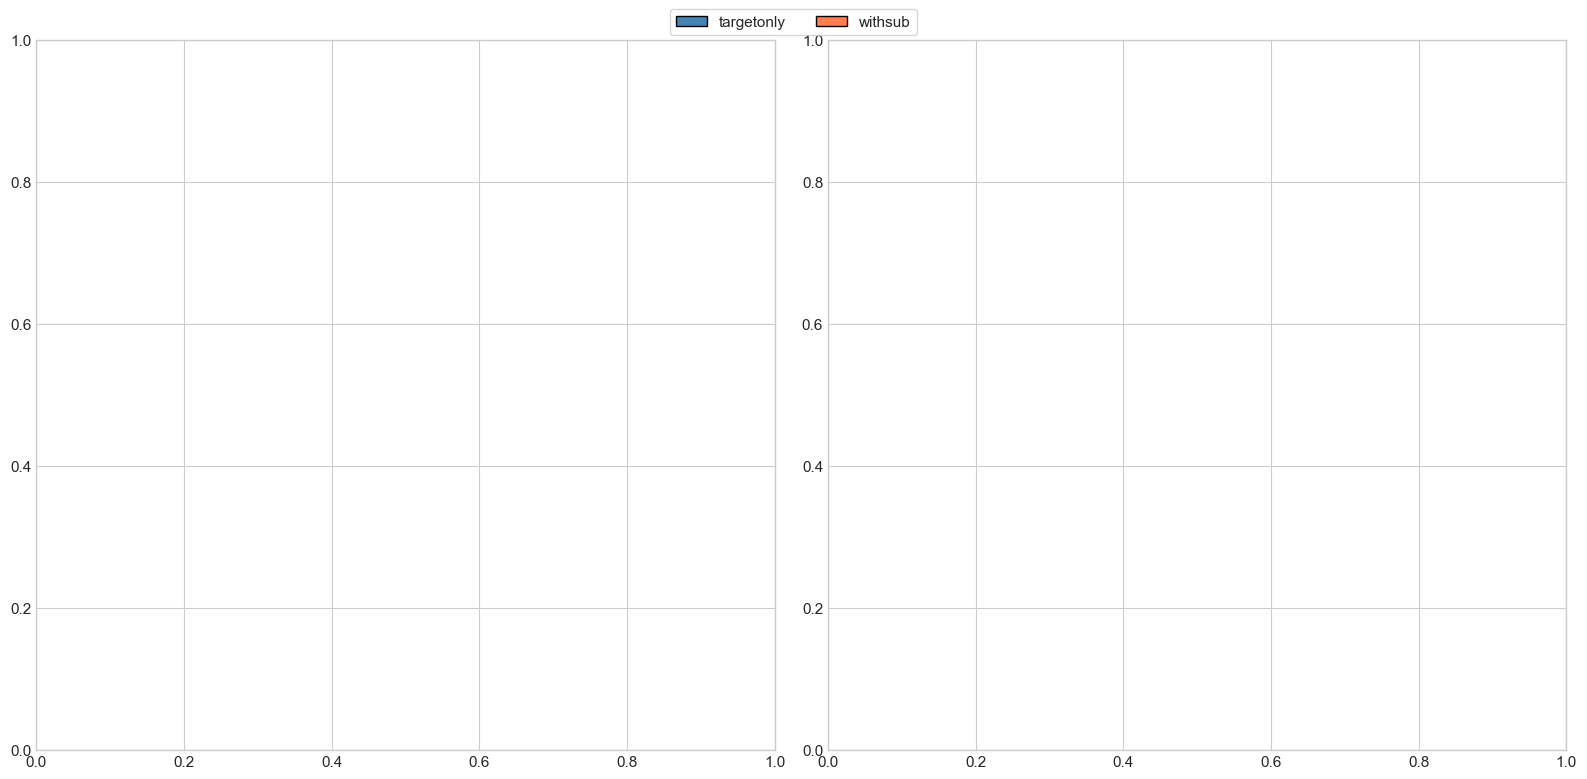

✓ Saved: coverage_comparison.png

2. Relation Type Heatmap...
No generated data for heatmap

3. Relation Type Stacked Bars...
No generated data

4. Mode Comparison (targetonly vs withsub)...
No generated data for mode comparison

5. SCAR Comparison Scatter...
Insufficient data for SCAR comparison

6. Summary Statistics Table...


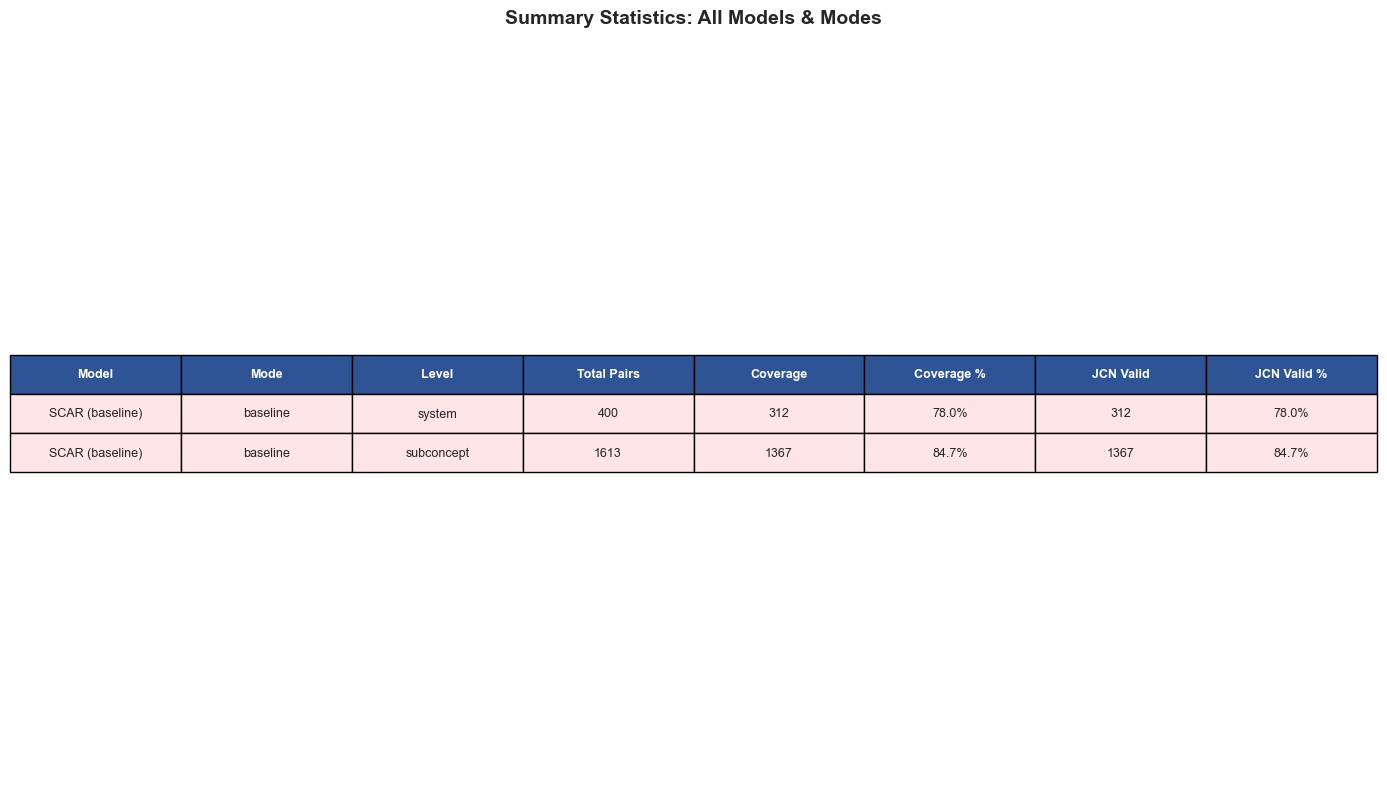

✓ Saved: summary_statistics.csv
✓ Saved: summary_table.png

✓ ALL VISUALIZATIONS COMPLETE!
Output directory: wordnet_outputs\visualizations

Summary Statistics:
          Model     Mode      Level  Total Pairs  Coverage Coverage %  JCN Valid JCN Valid %
SCAR (baseline) baseline     system          400       312      78.0%        312       78.0%
SCAR (baseline) baseline subconcept         1613      1367      84.7%       1367       84.7%


In [ ]:
# visalizations generated vs SCAR dataset 

PARSING SUMMARY FILES
✓ Parsed: summary_deepseek-r1_targetonly.txt
✓ Parsed: summary_deepseek-r1_withsub.txt
✓ Parsed: summary_gemini-2.5-flash-lite_targetonly.txt
✓ Parsed: summary_gemini-2.5-flash-lite_withsub.txt
✓ Parsed: summary_gpt-4.1-mini_targetonly.txt
✓ Parsed: summary_gpt-4.1-mini_withsub.txt
✓ Parsed: summary_gpt-4.1-nano_targetonly.txt
✓ Parsed: summary_gpt-4.1-nano_withsub.txt
✓ Parsed: summary_gpt-oss-120b_targetonly.txt
✓ Parsed: summary_gpt-oss-120b_withsub.txt
✓ Parsed: summary_gpt-oss-20b_targetonly.txt
✓ Parsed: summary_gpt-oss-20b_withsub.txt
✓ Parsed: summary_grok-4-fast_targetonly.txt
✓ Parsed: summary_grok-4-fast_withsub.txt
✓ Parsed: summary_llama-3.1-405b-instruct_targetonly.txt
✓ Parsed: summary_llama-3.1-405b-instruct_withsub.txt
✓ Parsed: summary_meta-llama-3-1-70b-instruct_targetonly.txt
✓ Parsed: summary_meta-llama-3-1-70b-instruct_withsub.txt
✓ Parsed: summary_meta-llama-3-1-8b-instruct_targetonly.txt
✓ Parsed: summary_meta-llama-3-1-8b-instruct_withsub.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


✓ Saved: wordnet_outputs\visualizations\relation_type_stacks.png

3. Creating summary table...
✓ Saved: wordnet_outputs\visualizations\summary_table_generated.png

✓ ALL VISUALIZATIONS COMPLETE!
Output directory: wordnet_outputs\visualizations


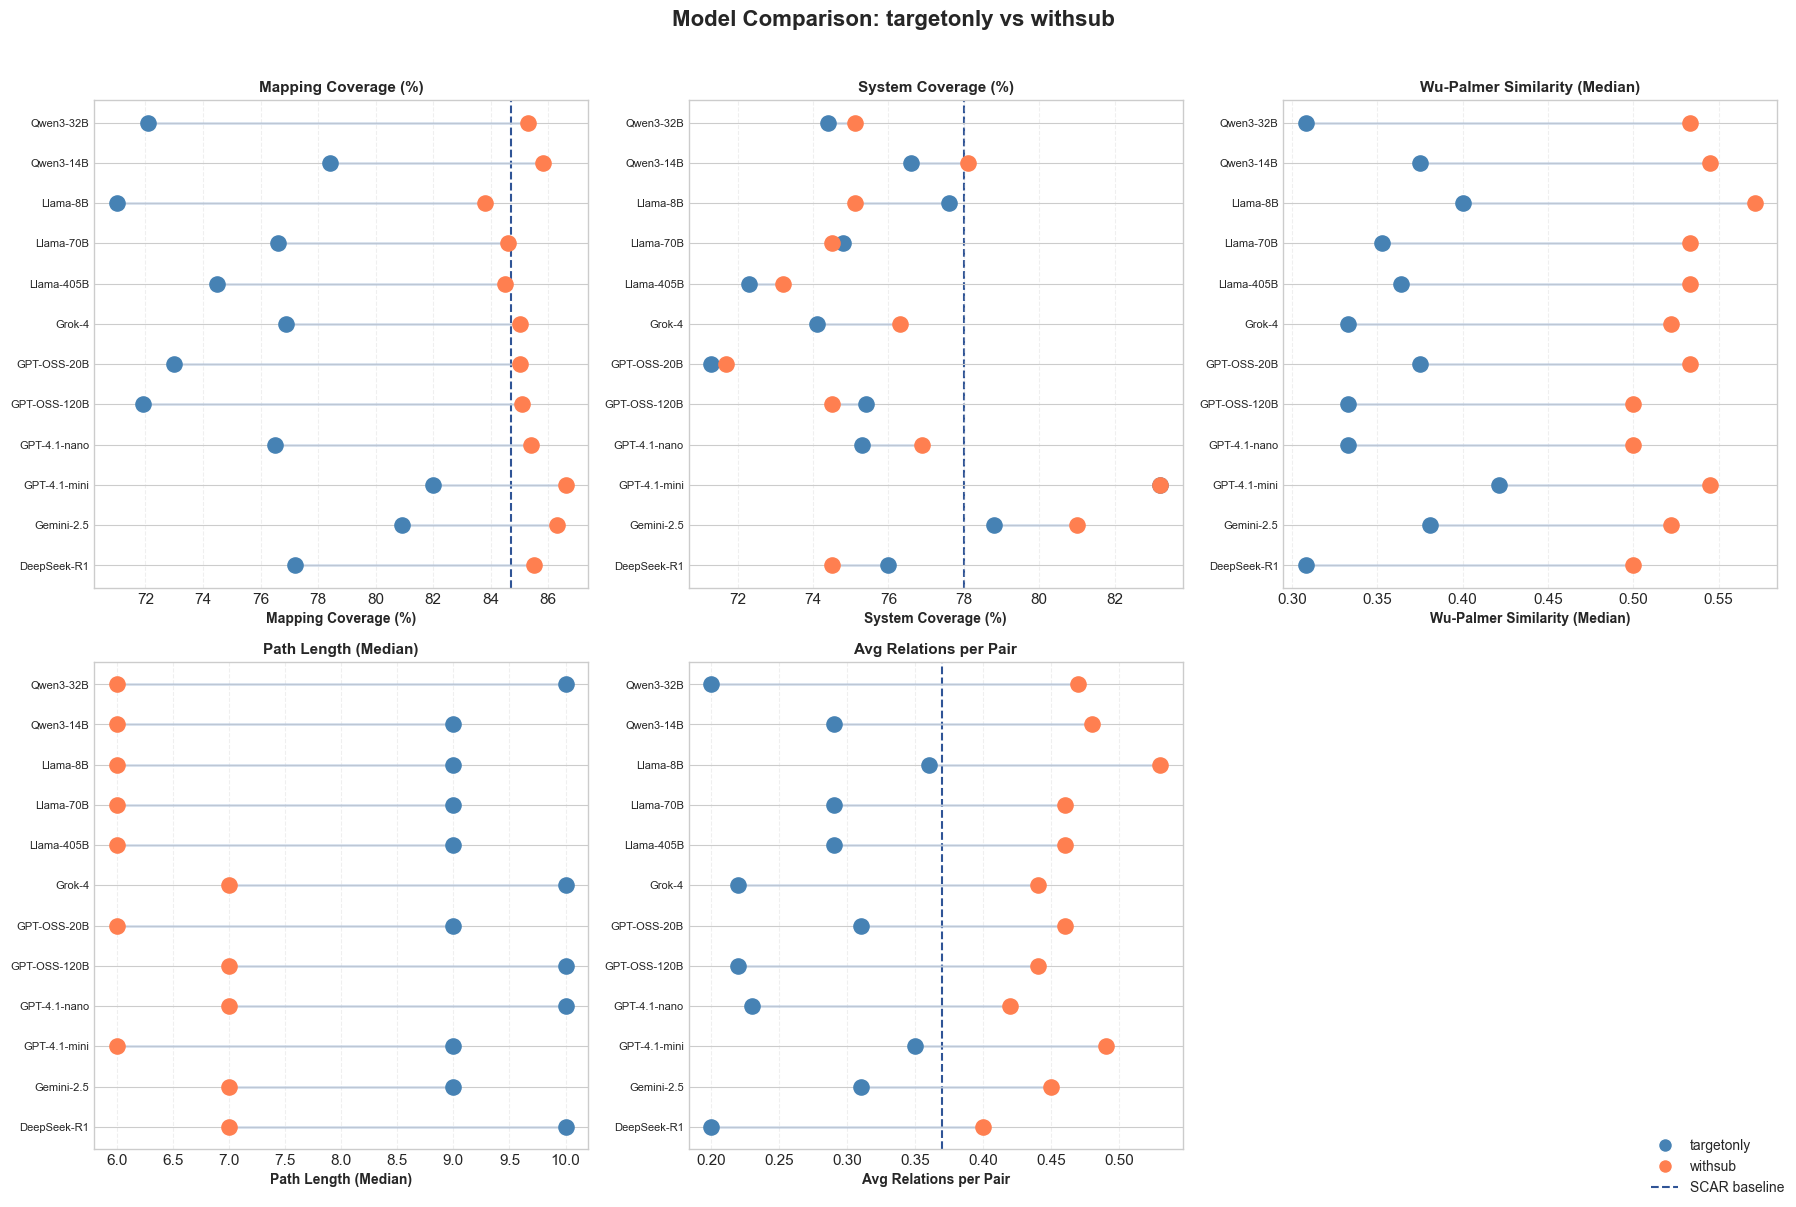

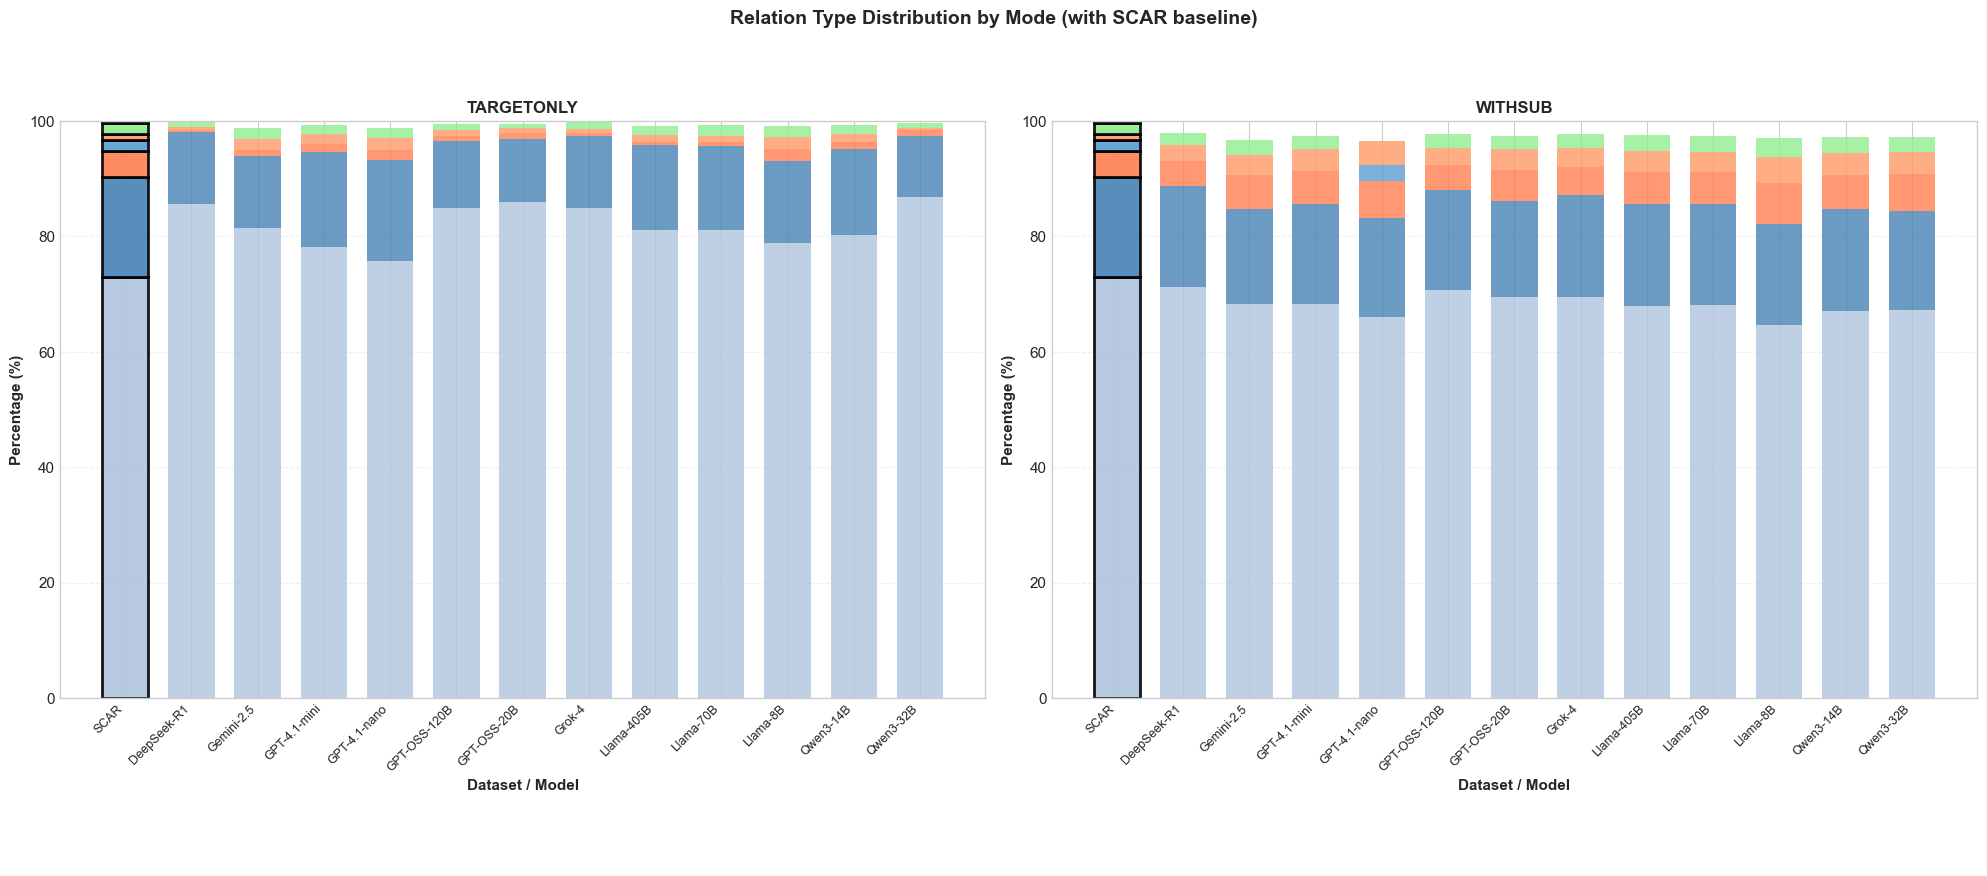

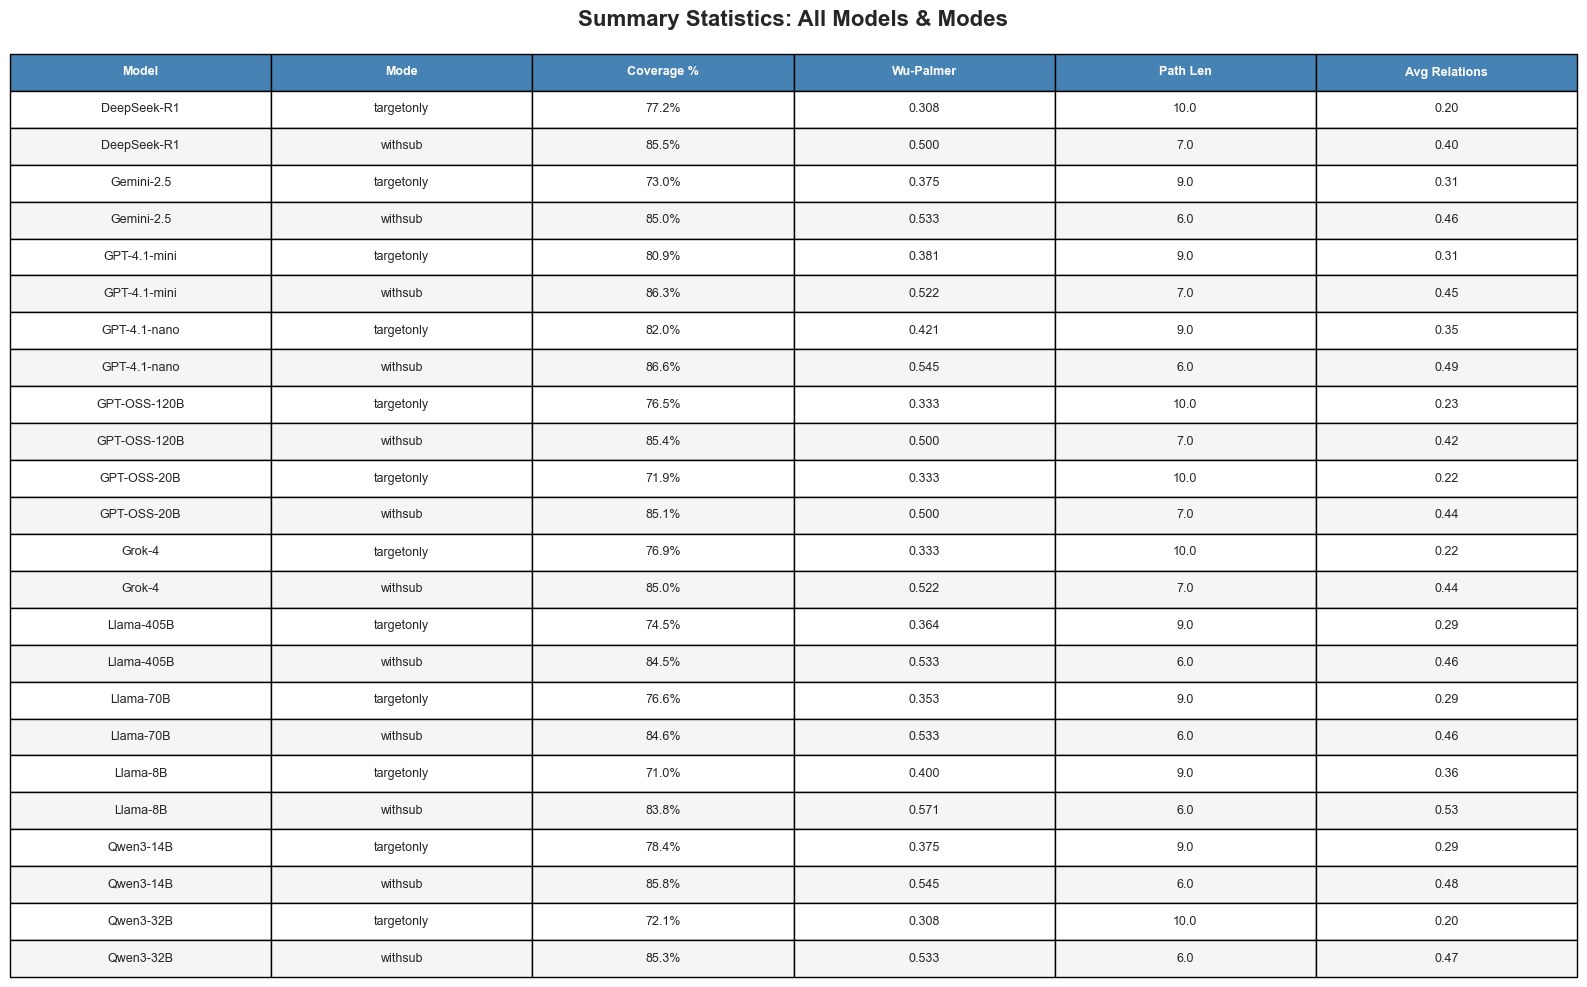

In [22]:
# Visualizations: Generated vs SCAR Dataset
import re
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.table import Table
import seaborn as sns

# Set up output directory
viz_dir = Path('wordnet_outputs/visualizations')
viz_dir.mkdir(parents=True, exist_ok=True)

# ============================================================================
# Parser Functions
# ============================================================================

def parse_summary_file(filepath):
    """Parse a single summary_*.txt file and extract metrics"""
    with open(filepath, 'r', encoding='utf-8') as f:
        content = f.read()
    
    # Extract model and mode from filename
    filename = Path(filepath).stem
    match = re.match(r'summary_(.+?)_(targetonly|withsub)', filename)
    if not match:
        return None
    
    model = match.group(1)
    mode = match.group(2)
    
    result = {
        'model': model,
        'mode': mode,
        'model_abbrev': get_model_abbrev(model)
    }
    
    # Parse dataset statistics
    match = re.search(r'Generated records: (\d+)', content)
    if match:
        result['generated_records'] = int(match.group(1))
    
    match = re.search(r'Generated mappings: (\d+)', content)
    if match:
        result['generated_mappings'] = int(match.group(1))
    
    # Parse coverage
    match = re.search(r'Generated mappings coverage: ([\d.]+)%', content)
    if match:
        result['gen_mappings_coverage_pct'] = float(match.group(1))
    
    match = re.search(r'Generated system pairs coverage: ([\d.]+)%', content)
    if match:
        result['gen_system_coverage_pct'] = float(match.group(1))
    
    # Parse similarity metrics (use median, ignore mean for JCN)
    match = re.search(r'Generated JCN.*?Median: ([\d.]+)', content)
    if match:
        result['jcn_median'] = float(match.group(1))
    
    match = re.search(r'Generated Wu-Palmer - Mean: ([\d.]+), Median: ([\d.]+)', content)
    if match:
        result['wup_mean'] = float(match.group(1))
        result['wup_median'] = float(match.group(2))
    
    match = re.search(r'Generated Path Length - Mean: ([\d.]+), Median: ([\d.]+)', content)
    if match:
        result['path_mean'] = float(match.group(1))
        result['path_median'] = float(match.group(2))
    
    # Parse relation types
    relation_types = ['none', 'shared-hypernym', 'same-synset', 'is-a', 'is-a-reverse', 
                      'co-hyponym', 'part-of', 'has-part', 'antonym', 'instance-of']
    
    # Find the "Generated top relations" section
    gen_relations_match = re.search(r'Generated top relations:(.*?)SCAR top relations:', content, re.DOTALL)
    if gen_relations_match:
        gen_section = gen_relations_match.group(1)
        for rel_type in relation_types:
            pattern = rf'\s+{re.escape(rel_type)}:\s+\d+\s+\(([\d.]+)%\)'
            match = re.search(pattern, gen_section)
            if match:
                result[f'rel_{rel_type.replace("-", "_")}_pct'] = float(match.group(1))
            else:
                result[f'rel_{rel_type.replace("-", "_")}_pct'] = 0.0
    
    # Parse relation richness
    match = re.search(r'Generated avg relations per pair: ([\d.]+)', content)
    if match:
        result['avg_relations_per_pair'] = float(match.group(1))
    
    match = re.search(r'Generated pairs with multiple relations: \d+ \(([\d.]+)%\)', content)
    if match:
        result['pct_pairs_multiple_relations'] = float(match.group(1))
    
    return result

def parse_scar_baseline(filepath):
    """Parse SCAR baseline metrics from analysis_summary.txt"""
    with open(filepath, 'r', encoding='utf-8') as f:
        content = f.read()
    
    result = {}
    
    # Parse coverage
    match = re.search(r'System pairs in WordNet: \d+ \(([\d.]+)%\)', content)
    if match:
        result['scar_system_coverage_pct'] = float(match.group(1))
    
    match = re.search(r'Subconcept pairs in WordNet: \d+ \(([\d.]+)%\)', content)
    if match:
        result['scar_subconcept_coverage_pct'] = float(match.group(1))
    
    # Parse similarity metrics (subconcepts)
    match = re.search(r'Wu-Palmer Similarity.*?Median: ([\d.]+)', content)
    if match:
        result['scar_wup_median'] = float(match.group(1))
    
    match = re.search(r'Path Length.*?Median: ([\d.]+)', content)
    if match:
        result['scar_path_median'] = float(match.group(1))
    
    match = re.search(r'JCN Similarity.*?Median: ([\d.]+)', content)
    if match:
        result['scar_jcn_median'] = float(match.group(1))
    
    # Parse relation richness
    match = re.search(r'Average relations per pair: ([\d.]+)', content)
    if match:
        result['scar_avg_relations_per_pair'] = float(match.group(1))
    
    # Parse relation types (Subconcepts section)
    relation_types = ['none', 'shared-hypernym', 'same-synset', 'is-a', 'is-a-reverse', 
                      'co-hyponym', 'part-of', 'has-part', 'antonym', 'instance-of']
    
    # Find the "TOP RELATION TYPES (Subconcepts):" section
    scar_relations_match = re.search(r'TOP RELATION TYPES \(Subconcepts\):(.*?)RELATION RICHNESS:', content, re.DOTALL)
    if scar_relations_match:
        scar_section = scar_relations_match.group(1)
        for rel_type in relation_types:
            pattern = rf'\s+{re.escape(rel_type)}:\s+\d+\s+\(([\d.]+)%\)'
            match = re.search(pattern, scar_section)
            if match:
                result[f'scar_rel_{rel_type.replace("-", "_")}_pct'] = float(match.group(1))
            else:
                result[f'scar_rel_{rel_type.replace("-", "_")}_pct'] = 0.0
    
    return result

# ============================================================================
# Load and Parse Data
# ============================================================================

print("=" * 80)
print("PARSING SUMMARY FILES")
print("=" * 80)

# Parse all generated summaries
summary_dir = Path('wordnet_outputs/generated_summaries')
summary_files = list(summary_dir.glob('summary_*.txt'))

all_results = []
for filepath in sorted(summary_files):
    result = parse_summary_file(filepath)
    if result:
        all_results.append(result)
        print(f"✓ Parsed: {filepath.name}")

df_gen_summary = pd.DataFrame(all_results)

# Parse SCAR baseline
scar_file = Path('wordnet_outputs/analysis_summary.txt')
scar_baseline = parse_scar_baseline(scar_file)

# Also parse SCAR relation types
with open(scar_file, 'r', encoding='utf-8') as f:
    scar_content = f.read()

relation_types = ['none', 'shared-hypernym', 'same-synset', 'is-a', 'is-a-reverse', 
                  'co-hyponym', 'part-of', 'has-part', 'antonym', 'instance-of']

scar_relations_match = re.search(r'TOP RELATION TYPES \(Subconcepts\):(.*?)RELATION RICHNESS:', scar_content, re.DOTALL)
if scar_relations_match:
    scar_section = scar_relations_match.group(1)
    for rel_type in relation_types:
        pattern = rf'\s+{re.escape(rel_type)}:\s+\d+\s+\(([\d.]+)%\)'
        match = re.search(pattern, scar_section)
        if match:
            scar_baseline[f'scar_rel_{rel_type.replace("-", "_")}_pct'] = float(match.group(1))
        else:
            scar_baseline[f'scar_rel_{rel_type.replace("-", "_")}_pct'] = 0.0

print(f"\n✓ Parsed SCAR baseline: {scar_file}")
print(f"✓ Parsed SCAR relation types")

print(f"\nLoaded {len(df_gen_summary)} model-mode combinations")
print(f"Models: {sorted(df_gen_summary['model'].unique())}")
print(f"Modes: {sorted(df_gen_summary['mode'].unique())}")

# Fill missing values with 0
for col in df_gen_summary.columns:
    if col.startswith('rel_') and col.endswith('_pct'):
        df_gen_summary[col] = df_gen_summary[col].fillna(0.0)

# ============================================================================
# Export CSV
# ============================================================================

csv_path = viz_dir / 'generated_summary_metrics.csv'
df_gen_summary.to_csv(csv_path, index=False)
print(f"\n✓ Saved: {csv_path}")

# ============================================================================
# Visualization Functions
# ============================================================================

def create_dumbbell_plot(df, metric_col, ylabel, scar_value=None, title_suffix=""):
    """Create a dumbbell plot comparing targetonly vs withsub for a metric"""
    # Pivot to have targetonly and withsub as columns
    df_pivot = df.pivot_table(
        index=['model_abbrev', 'model'],
        columns='mode',
        values=metric_col,
        aggfunc='first'
    ).reset_index()
    
    # Sort by model order (consistent with original list)
    model_order = ['deepseek-r1', 'gemini-2.5-flash-lite', 'gpt-4.1-mini', 'gpt-4.1-nano',
                   'gpt-oss-120b', 'gpt-oss-20b', 'grok-4-fast', 'llama-3.1-405b-instruct',
                   'meta-llama-3-1-70b-instruct', 'meta-llama-3-1-8b-instruct',
                   'qwen3-14b', 'qwen3-32b']
    
    df_pivot['model_order'] = df_pivot['model'].apply(lambda x: model_order.index(x) if x in model_order else 999)
    df_pivot = df_pivot.sort_values('model_order')
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    y_pos = range(len(df_pivot))
    
    # Plot dumbbells
    for i, row in df_pivot.iterrows():
        y = y_pos[i]
        targetonly_val = row.get('targetonly', None)
        withsub_val = row.get('withsub', None)
        
        if pd.notna(targetonly_val) and pd.notna(withsub_val):
            # Draw line
            ax.plot([targetonly_val, withsub_val], [y, y], 
                   color=COLORS['light'], linewidth=2, alpha=0.5, zorder=1)
            # Draw points
            ax.scatter(targetonly_val, y, s=150, color=COLORS['primary'], 
                     zorder=2, label='targetonly' if i == 0 else '')
            ax.scatter(withsub_val, y, s=150, color=COLORS['secondary'], 
                     zorder=2, label='withsub' if i == 0 else '')
        elif pd.notna(targetonly_val):
            ax.scatter(targetonly_val, y, s=150, color=COLORS['primary'], zorder=2)
        elif pd.notna(withsub_val):
            ax.scatter(withsub_val, y, s=150, color=COLORS['secondary'], zorder=2)
    
    # Add SCAR baseline line if provided
    if scar_value is not None and pd.notna(scar_value):
        ax.axvline(scar_value, color=COLORS['dark'], linestyle='--', linewidth=2, 
                  label='SCAR baseline', zorder=0)
        ax.text(scar_value, len(df_pivot) - 0.5, f'SCAR: {scar_value:.1f}',
               rotation=0, va='bottom', ha='right', fontsize=10, 
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_pivot['model_abbrev'].values)
    ax.set_xlabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_ylabel('Model', fontsize=12, fontweight='bold')
    ax.set_title(f'Model Comparison: {ylabel}{title_suffix}', fontsize=14, fontweight='bold', pad=20)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.legend(loc='best', fontsize=10)
    
    plt.tight_layout()
    return fig

def create_relation_stacks(df, mode_name):
    """Create stacked bar chart for relation types"""
    df_mode = df[df['mode'] == mode_name].copy()
    
    # Get relation type columns
    rel_cols = [col for col in df_mode.columns if col.startswith('rel_') and col.endswith('_pct')]
    
    # Sort by model order
    model_order = ['deepseek-r1', 'gemini-2.5-flash-lite', 'gpt-4.1-mini', 'gpt-4.1-nano',
                   'gpt-oss-120b', 'gpt-oss-20b', 'grok-4-fast', 'llama-3.1-405b-instruct',
                   'meta-llama-3-1-70b-instruct', 'meta-llama-3-1-8b-instruct',
                   'qwen3-14b', 'qwen3-32b']
    
    df_mode['model_order'] = df_mode['model'].apply(lambda x: model_order.index(x) if x in model_order else 999)
    df_mode = df_mode.sort_values('model_order')
    
    # Prepare data for stacking
    rel_data = {}
    for col in rel_cols:
        rel_name = col.replace('rel_', '').replace('_pct', '').replace('_', '-')
        rel_data[rel_name] = df_mode[col].values
    
    # Select top categories + other
    top_categories = ['none', 'shared-hypernym', 'same-synset', 'is-a', 'is-a-reverse', 'co-hyponym']
    other_categories = [k for k in rel_data.keys() if k not in top_categories]
    
    # Combine others
    if other_categories:
        rel_data['other'] = sum([rel_data[k] for k in other_categories if k in rel_data])
    
    # Keep only top categories + other
    plot_data = {k: rel_data[k] for k in top_categories + ['other'] if k in rel_data}
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    x_pos = range(len(df_mode))
    bottom = np.zeros(len(df_mode))
    
    # Color mapping for relation types
    rel_colors = {
        'none': COLORS['light'],
        'shared-hypernym': COLORS['primary'],
        'same-synset': COLORS['secondary'],
        'is-a': COLORS['accent1'],
        'is-a-reverse': COLORS['accent2'],
        'co-hyponym': '#90EE90',
        'other': '#D3D3D3'
    }
    
    for rel_type, values in plot_data.items():
        color = rel_colors.get(rel_type, '#808080')
        ax.bar(x_pos, values, bottom=bottom, label=rel_type.replace('-', ' ').title(), 
              color=color, alpha=0.8, width=0.7)
        bottom += values
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(df_mode['model_abbrev'].values, rotation=45, ha='right')
    ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax.set_title(f'Relation Type Distribution: {mode_name.upper()}', fontsize=14, fontweight='bold', pad=20)
    ax.set_ylim(0, 100)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    return fig

def create_summary_table(df):
    """Create a styled table figure"""
    # Prepare table data
    table_data = []
    
    # Sort by model order
    model_order = ['deepseek-r1', 'gemini-2.5-flash-lite', 'gpt-4.1-mini', 'gpt-4.1-nano',
                   'gpt-oss-120b', 'gpt-oss-20b', 'grok-4-fast', 'llama-3.1-405b-instruct',
                   'meta-llama-3-1-70b-instruct', 'meta-llama-3-1-8b-instruct',
                   'qwen3-14b', 'qwen3-32b']
    
    df_sorted = df.copy()
    df_sorted['model_order'] = df_sorted['model'].apply(lambda x: model_order.index(x) if x in model_order else 999)
    df_sorted = df_sorted.sort_values(['model_order', 'mode'])
    
    # Create table rows
    for _, row in df_sorted.iterrows():
        table_data.append([
            row['model_abbrev'],
            row['mode'],
            f"{row.get('gen_mappings_coverage_pct', 0):.1f}%",
            f"{row.get('wup_median', 0):.3f}",
            f"{row.get('path_median', 0):.1f}",
            f"{row.get('avg_relations_per_pair', 0):.2f}"
        ])
    
    fig, ax = plt.subplots(figsize=(16, max(10, len(table_data) * 0.4)))
    ax.axis('tight')
    ax.axis('off')
    
    table = ax.table(
        cellText=table_data,
        colLabels=['Model', 'Mode', 'Coverage %', 'Wu-Palmer', 'Path Len', 'Avg Relations'],
        cellLoc='center',
        loc='center',
        bbox=[0, 0, 1, 1]
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    
    # Style header
    for i in range(6):
        table[(0, i)].set_facecolor(COLORS['primary'])
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Alternate row colors
    for i in range(1, len(table_data) + 1):
        for j in range(6):
            if i % 2 == 0:
                table[(i, j)].set_facecolor('#F5F5F5')
            else:
                table[(i, j)].set_facecolor('white')
    
    ax.set_title('Summary Statistics: All Models & Modes', fontsize=16, fontweight='bold', pad=20)
    
    plt.tight_layout()
    return fig

# ============================================================================
# Generate Visualizations
# ============================================================================

print("\n" + "=" * 80)
print("GENERATING VISUALIZATIONS")
print("=" * 80)

# 1. Dumbbell plots
print("\n1. Creating dumbbell plots...")

metrics_to_plot = [
    ('gen_mappings_coverage_pct', 'Mapping Coverage (%)', scar_baseline.get('scar_subconcept_coverage_pct')),
    ('gen_system_coverage_pct', 'System Coverage (%)', scar_baseline.get('scar_system_coverage_pct')),
    ('wup_median', 'Wu-Palmer Similarity (Median)', scar_baseline.get('scar_wup_median')),
    ('path_median', 'Path Length (Median)', scar_baseline.get('scar_path_median')),
    ('avg_relations_per_pair', 'Avg Relations per Pair', scar_baseline.get('scar_avg_relations_per_pair'))
]

fig_dumbbells, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (metric_col, ylabel, scar_val) in enumerate(metrics_to_plot):
    if idx >= len(axes):
        break
    
    ax = axes[idx]
    
    # Pivot data
    df_pivot = df_gen_summary.pivot_table(
        index=['model_abbrev', 'model'],
        columns='mode',
        values=metric_col,
        aggfunc='first'
    ).reset_index()
    
    # Sort by model order
    model_order = ['deepseek-r1', 'gemini-2.5-flash-lite', 'gpt-4.1-mini', 'gpt-4.1-nano',
                   'gpt-oss-120b', 'gpt-oss-20b', 'grok-4-fast', 'llama-3.1-405b-instruct',
                   'meta-llama-3-1-70b-instruct', 'meta-llama-3-1-8b-instruct',
                   'qwen3-14b', 'qwen3-32b']
    
    df_pivot['model_order'] = df_pivot['model'].apply(lambda x: model_order.index(x) if x in model_order else 999)
    df_pivot = df_pivot.sort_values('model_order')
    
    y_pos = range(len(df_pivot))
    
    # Plot dumbbells
    for i, row in df_pivot.iterrows():
        y = y_pos[i]
        targetonly_val = row.get('targetonly', None)
        withsub_val = row.get('withsub', None)
        
        if pd.notna(targetonly_val) and pd.notna(withsub_val):
            ax.plot([targetonly_val, withsub_val], [y, y], 
                   color=COLORS['light'], linewidth=2, alpha=0.5, zorder=1)
            ax.scatter(targetonly_val, y, s=120, color=COLORS['primary'], zorder=2)
            ax.scatter(withsub_val, y, s=120, color=COLORS['secondary'], zorder=2)
        elif pd.notna(targetonly_val):
            ax.scatter(targetonly_val, y, s=120, color=COLORS['primary'], zorder=2)
        elif pd.notna(withsub_val):
            ax.scatter(withsub_val, y, s=120, color=COLORS['secondary'], zorder=2)
    
    # Add SCAR baseline
    if scar_val is not None and pd.notna(scar_val):
        ax.axvline(scar_val, color=COLORS['dark'], linestyle='--', linewidth=1.5, zorder=0)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_pivot['model_abbrev'].values, fontsize=8)
    ax.set_xlabel(ylabel, fontsize=10, fontweight='bold')
    ax.set_title(ylabel, fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')

# Remove empty subplot
if len(metrics_to_plot) < len(axes):
    fig_dumbbells.delaxes(axes[len(metrics_to_plot)])

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS['primary'], 
           markersize=10, label='targetonly'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS['secondary'], 
           markersize=10, label='withsub'),
    Line2D([0], [0], color=COLORS['dark'], linestyle='--', linewidth=1.5, label='SCAR baseline')
]
fig_dumbbells.legend(handles=legend_elements, loc='lower right', fontsize=10)

fig_dumbbells.suptitle('Model Comparison: targetonly vs withsub', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])

dumbbell_path = viz_dir / 'metric_dumbbells.png'
fig_dumbbells.savefig(dumbbell_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {dumbbell_path}")

# 2. Relation type stacked bars (with SCAR baseline)
print("\n2. Creating relation type stacked bar charts...")

# Prepare SCAR relation type data
scar_rel_data = {}
top_categories = ['none', 'shared-hypernym', 'same-synset', 'is-a', 'is-a-reverse', 'co-hyponym']
for rel_type in top_categories:
    key = f'scar_rel_{rel_type.replace("-", "_")}_pct'
    scar_rel_data[rel_type] = scar_baseline.get(key, 0.0)

# Add other categories for SCAR
other_scar_types = ['part-of', 'has-part', 'antonym', 'instance-of']
other_scar_sum = sum([scar_baseline.get(f'scar_rel_{t.replace("-", "_")}_pct', 0.0) for t in other_scar_types])
if other_scar_sum > 0:
    scar_rel_data['other'] = other_scar_sum
else:
    scar_rel_data['other'] = 0.0

fig_stacks, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

for mode_idx, (mode_name, ax) in enumerate([('targetonly', ax1), ('withsub', ax2)]):
    df_mode = df_gen_summary[df_gen_summary['mode'] == mode_name].copy()
    
    # Get relation type columns
    rel_cols = [col for col in df_mode.columns if col.startswith('rel_') and col.endswith('_pct')]
    
    # Sort by model order
    model_order = ['deepseek-r1', 'gemini-2.5-flash-lite', 'gpt-4.1-mini', 'gpt-4.1-nano',
                   'gpt-oss-120b', 'gpt-oss-20b', 'grok-4-fast', 'llama-3.1-405b-instruct',
                   'meta-llama-3-1-70b-instruct', 'meta-llama-3-1-8b-instruct',
                   'qwen3-14b', 'qwen3-32b']
    
    df_mode['model_order'] = df_mode['model'].apply(lambda x: model_order.index(x) if x in model_order else 999)
    df_mode = df_mode.sort_values('model_order')
    
    # Prepare data
    rel_data = {}
    for col in rel_cols:
        rel_name = col.replace('rel_', '').replace('_pct', '').replace('_', '-')
        rel_data[rel_name] = df_mode[col].fillna(0).values
    
    # Select top categories + other
    other_categories = [k for k in rel_data.keys() if k not in top_categories]
    
    if other_categories:
        rel_data['other'] = sum([rel_data.get(k, np.zeros(len(df_mode))) for k in other_categories])
    
    plot_data = {k: rel_data[k] for k in top_categories + ['other'] if k in rel_data}
    
    # Add SCAR as the first bar (position 0)
    x_pos = range(len(df_mode) + 1)  # +1 for SCAR
    bottom = np.zeros(len(df_mode) + 1)
    scar_bottom = np.zeros(1)
    
    rel_colors = {
        'none': COLORS['light'],
        'shared-hypernym': COLORS['primary'],
        'same-synset': COLORS['secondary'],
        'is-a': COLORS['accent1'],
        'is-a-reverse': COLORS['accent2'],
        'co-hyponym': '#90EE90',
        'other': '#D3D3D3'
    }
    
    # Plot SCAR baseline bar first (at position 0)
    for rel_type in top_categories + ['other']:
        if rel_type in scar_rel_data:
            color = rel_colors.get(rel_type, '#808080')
            ax.bar(0, scar_rel_data[rel_type], bottom=scar_bottom[0], 
                  color=color, alpha=0.9, width=0.7, edgecolor='black', linewidth=2)
            scar_bottom[0] += scar_rel_data[rel_type]
    
    # Plot model bars (starting at position 1)
    for i in range(len(df_mode)):
        model_bottom = bottom[i + 1]
        for rel_type, values in plot_data.items():
            color = rel_colors.get(rel_type, '#808080')
            ax.bar(i + 1, values[i], bottom=model_bottom, 
                  color=color, alpha=0.8, width=0.7)
            model_bottom += values[i]
    
    # Set x-axis labels (SCAR + models)
    x_labels = ['SCAR'] + df_mode['model_abbrev'].tolist()
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Dataset / Model', fontsize=11, fontweight='bold')
    ax.set_title(f'{mode_name.upper()}', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

fig_stacks.suptitle('Relation Type Distribution by Mode (with SCAR baseline)', fontsize=14, fontweight='bold', y=1.0)
fig_stacks.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=7, fontsize=9)
plt.tight_layout(rect=[0, 0, 1, 0.95])

stack_path = viz_dir / 'relation_type_stacks.png'
fig_stacks.savefig(stack_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {stack_path}")

# 3. Summary table
print("\n3. Creating summary table...")

fig_table = create_summary_table(df_gen_summary)
table_path = viz_dir / 'summary_table_generated.png'
fig_table.savefig(table_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {table_path}")

print("\n" + "=" * 80)
print("✓ ALL VISUALIZATIONS COMPLETE!")
print(f"Output directory: {viz_dir}")
print("=" * 80)

✓ Updated SCAR baseline with relation types

2b. Creating relation type stacked bar charts with SCAR...
✓ Saved (updated with SCAR): wordnet_outputs\visualizations\relation_type_stacks.png


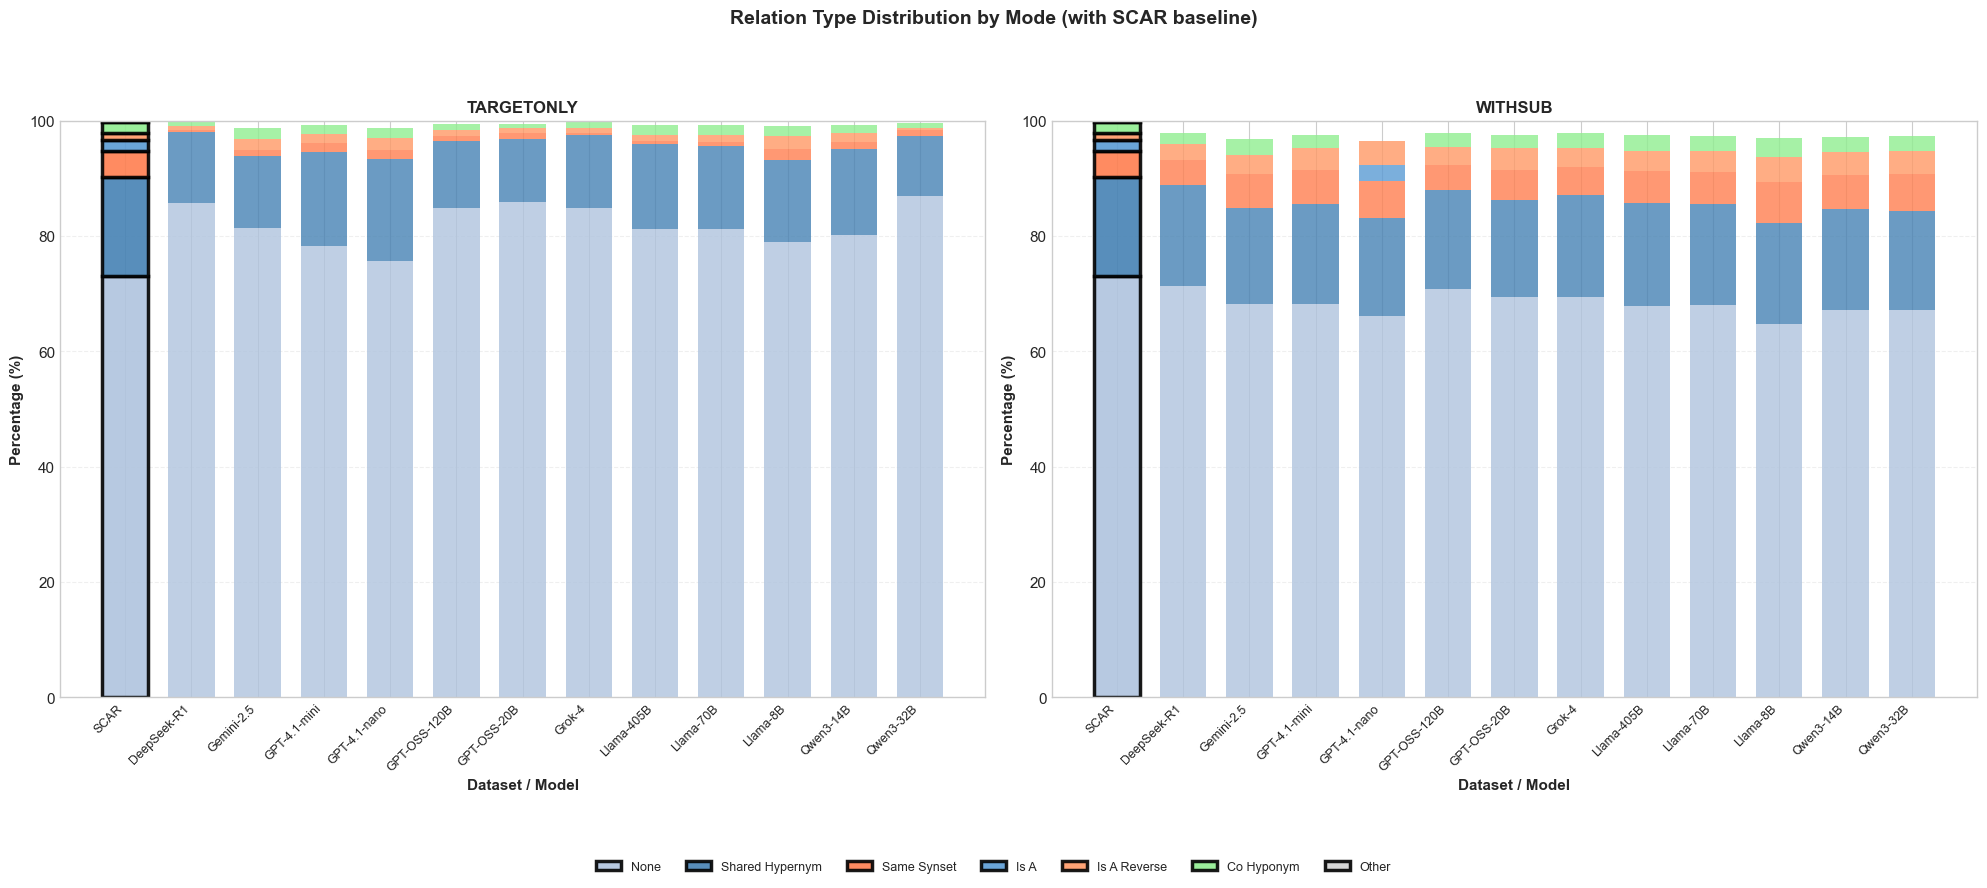

In [23]:
# Update: Add SCAR relation types to the visualization
# Re-parse SCAR to extract relation types and regenerate the chart

# Parse SCAR relation types from analysis_summary.txt
scar_file = Path('wordnet_outputs/analysis_summary.txt')
with open(scar_file, 'r', encoding='utf-8') as f:
    scar_content = f.read()

relation_types = ['none', 'shared-hypernym', 'same-synset', 'is-a', 'is-a-reverse', 
                  'co-hyponym', 'part-of', 'has-part', 'antonym', 'instance-of']

scar_relations_match = re.search(r'TOP RELATION TYPES \(Subconcepts\):(.*?)RELATION RICHNESS:', scar_content, re.DOTALL)
if scar_relations_match:
    scar_section = scar_relations_match.group(1)
    for rel_type in relation_types:
        pattern = rf'\s+{re.escape(rel_type)}:\s+\d+\s+\(([\d.]+)%\)'
        match = re.search(pattern, scar_section)
        if match:
            scar_baseline[f'scar_rel_{rel_type.replace("-", "_")}_pct'] = float(match.group(1))
        else:
            scar_baseline[f'scar_rel_{rel_type.replace("-", "_")}_pct'] = 0.0

print("✓ Updated SCAR baseline with relation types")

# Regenerate the relation type stacked bar charts with SCAR included
print("\n2b. Creating relation type stacked bar charts with SCAR...")

fig_stacks_v2, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

for mode_idx, (mode_name, ax) in enumerate([('targetonly', ax1), ('withsub', ax2)]):
    df_mode = df_gen_summary[df_gen_summary['mode'] == mode_name].copy()
    
    # Get relation type columns
    rel_cols = [col for col in df_mode.columns if col.startswith('rel_') and col.endswith('_pct')]
    
    # Sort by model order
    model_order = ['deepseek-r1', 'gemini-2.5-flash-lite', 'gpt-4.1-mini', 'gpt-4.1-nano',
                   'gpt-oss-120b', 'gpt-oss-20b', 'grok-4-fast', 'llama-3.1-405b-instruct',
                   'meta-llama-3-1-70b-instruct', 'meta-llama-3-1-8b-instruct',
                   'qwen3-14b', 'qwen3-32b']
    
    df_mode['model_order'] = df_mode['model'].apply(lambda x: model_order.index(x) if x in model_order else 999)
    df_mode = df_mode.sort_values('model_order')
    
    # Prepare SCAR relation type data
    scar_rel_data = {}
    top_categories = ['none', 'shared-hypernym', 'same-synset', 'is-a', 'is-a-reverse', 'co-hyponym']
    for rel_type in top_categories:
        key = f'scar_rel_{rel_type.replace("-", "_")}_pct'
        scar_rel_data[rel_type] = scar_baseline.get(key, 0.0)
    
    # Add other categories for SCAR
    other_scar_types = ['part-of', 'has-part', 'antonym', 'instance-of']
    other_scar_sum = sum([scar_baseline.get(f'scar_rel_{t.replace("-", "_")}_pct', 0.0) for t in other_scar_types])
    if other_scar_sum > 0:
        scar_rel_data['other'] = other_scar_sum
    else:
        scar_rel_data['other'] = 0.0
    
    # Prepare model data
    rel_data = {}
    for col in rel_cols:
        rel_name = col.replace('rel_', '').replace('_pct', '').replace('_', '-')
        rel_data[rel_name] = df_mode[col].fillna(0).values
    
    # Select top categories + other
    other_categories = [k for k in rel_data.keys() if k not in top_categories]
    
    if other_categories:
        rel_data['other'] = sum([rel_data.get(k, np.zeros(len(df_mode))) for k in other_categories])
    
    plot_data = {k: rel_data[k] for k in top_categories + ['other'] if k in rel_data}
    
    # Add SCAR as the first bar (position 0)
    x_pos = list(range(len(df_mode) + 1))  # +1 for SCAR
    bottom = np.zeros(len(df_mode) + 1)
    scar_bottom = np.zeros(1)
    
    rel_colors = {
        'none': COLORS['light'],
        'shared-hypernym': COLORS['primary'],
        'same-synset': COLORS['secondary'],
        'is-a': COLORS['accent1'],
        'is-a-reverse': COLORS['accent2'],
        'co-hyponym': '#90EE90',
        'other': '#D3D3D3'
    }
    
    # Plot SCAR baseline bar first (at position 0) with black border to distinguish
    for rel_type in top_categories + ['other']:
        if rel_type in scar_rel_data:
            color = rel_colors.get(rel_type, '#808080')
            ax.bar(0, scar_rel_data[rel_type], bottom=scar_bottom[0], 
                  color=color, alpha=0.9, width=0.7, edgecolor='black', linewidth=2.5,
                  label=rel_type.replace('-', ' ').title() if mode_idx == 0 else '')
            scar_bottom[0] += scar_rel_data[rel_type]
    
    # Plot model bars (starting at position 1)
    for i in range(len(df_mode)):
        model_bottom = bottom[i + 1]
        for rel_type, values in plot_data.items():
            color = rel_colors.get(rel_type, '#808080')
            ax.bar(i + 1, values[i], bottom=model_bottom, 
                  color=color, alpha=0.8, width=0.7)
            model_bottom += values[i]
    
    # Set x-axis labels (SCAR + models)
    x_labels = ['SCAR'] + df_mode['model_abbrev'].tolist()
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Dataset / Model', fontsize=11, fontweight='bold')
    ax.set_title(f'{mode_name.upper()}', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

fig_stacks_v2.suptitle('Relation Type Distribution by Mode (with SCAR baseline)', fontsize=14, fontweight='bold', y=1.0)
fig_stacks_v2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=7, fontsize=9)
plt.tight_layout(rect=[0, 0, 1, 0.95])

stack_path_v2 = viz_dir / 'relation_type_stacks.png'
fig_stacks_v2.savefig(stack_path_v2, dpi=300, bbox_inches='tight')
print(f"✓ Saved (updated with SCAR): {stack_path_v2}")